In [ ]:
'''
I. Data
1. Handle
- Check and find one row missing -> delete row (still 214 n/a for phone provider: handle later)
- Split 8/2 for Train+ Validation/ OOT
- N/a: loan_data['phone_provider'].fillna('viettel') #fill with mode
- Outlier: boxplot. 
+ money features (like INCOME or OUTS_BAL)  
+ age: 124 wrong -> 
+ income: mean+ 3std
+ other: clip 1st, 99th percentile. (other ways: 5th, 95th; mean/median + 3 std)
(any value above the 99th percentile becomes the 99th percentile value)





'''

In [ ]:
# pip install lightgbm 
# pip install shap

In [2]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate, cross_val_predict,
    StratifiedKFold, GridSearchCV, ParameterGrid
)
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, RocCurveDisplay, fbeta_score, make_scorer, auc,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, StackingClassifier, ExtraTreesClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import shap
import joblib # to store the choosen/best model for later

# I. Data Preparation

In [3]:
loan_data_backup = pd.read_excel('1. Model Professional Test.xlsx', sheet_name='Dataset')

In [116]:
loan_data_all = loan_data_backup.copy()

In [117]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)     

# missing = loan_data_all.isna().sum()

# print(missing[missing > 0])

# delete 1 row which has lots of missing values. 
# loan_data_all[loan_data_all['gender'].isna()]

loan_data_all = loan_data_all.dropna(subset=['gender'])
# missing = loan_data_all.isna().sum()

# print(missing[missing > 0])

# now we will split into loan_data and loan_data_PSI, (we handle n/a in phone_provider after the split)

# sort by time
loan_data_all = loan_data_all.sort_values('disbursement_date')

# split point (80%)
split_idx = int(len(loan_data_all) * 0.8)

# earlier 80%
loan_data = loan_data_all.iloc[:split_idx]

# latest 20% (for PSI/OOT)
loan_data_PSI = loan_data_all.iloc[split_idx:]

#from now on, in this notebook we work with loan_data only (for training and testing).
#loan_data_PSI will be in different notebook

# loan_data.info()

### HANDLE DISCRETE FEATURES
gender, phone, opera, address, date-> number  (months since disburment)

In [118]:
# loan_data['gender'].unique()

#still na for phone  provider 
# loan_data['phone_provider'].value_counts(dropna=False)

# can replace by mode (viettel in this case) or find 'similar' customers 
#(i.e if missing occupation, can use age and income to guess for occupation)
loan_data2=loan_data.copy()
loan_data2['phone_provider']= loan_data['phone_provider'].fillna('viettel')

# ADDRESS . you can just run whole code below
x = pd.DataFrame()

# # STEP 1
x['a'] = (
    loan_data2['address_apply']
    .str.extract(r',\s*([^,]+)\s*,\s*[^,]+$')[0]
)

x['a'] = (
    x['a']
    .str.replace(r'\d+', '', regex=True)
    .str.replace(r'\b(Province|Thành phố|City)\b', '', regex=True)
    .str.strip()
)

# if NaN after STEP 1 -> take last 2 words before first comma
x['a'] = x['a'].mask(
    x['a'].isna(),
    loan_data2['address_apply']
    .str.extract(r'([^,]+),')[0] # take text before first comma
    .str.split()  #split into words
    .str[-2:] #take last 2 words
    .str.join(' ') #join back
)

# if '' after STEP 1 -> take 3rd-last part
x['a'] = x['a'].mask(
    x['a'] == '',
    loan_data2['address_apply']
    .str.extract(r',\s*([^,]+)\s*,\s*[^,]+\s*,\s*[^,]+$')[0]
)
# x['a'].unique()

# if data contains 'Hanoi' then "HN"
# if contains 'Province', 'Thành phố', 'City' drop theses words
# if 'Ba Ria - Vung Tau' then "BRVT"
# then give only the first charaters of the word (after drop 'Province', 'Thành phố', 'City') i.e 'An Giang' gives "AG", Ha Noi gives "HN"..

loan_data2['address']= x['a']

# custom replacements
loan_data2['address'] = loan_data2['address'].replace({
    'Hanoi': 'HN',
    'Ha Noi': 'HN',
    'Bà Rịa - Vũng Tàu': 'BRVT',
    'Ba Ria - Vung Tau': 'BRVT',
    'Đồng Nai': 'DNN',
    'Dong Nai': 'DNN',
    'Đà Nẵng': 'DN',
    'Da Nang':'DN',
    'Dak Nong': 'DkN',
    'Đắk Nông': 'DkN'
    
})

loan_data2['address'] = loan_data2['address'].apply(
    lambda x: x
    if x in ['HN', 'BRVT', 'DNN', 'DN', 'DkN']
    else ''.join(word[0] for word in str(x).split()).upper()
)

loan_data2['address'].unique()

array(['HCM', 'ĐT', 'DN', 'PT', 'AG', 'LA', 'HN', 'BG', 'BĐ', 'LĐ', 'BD',
       'DNN', 'TB', 'TN', 'HY', 'HD', 'CT', 'NB', 'TH', 'TV', 'TTH',
       'BRVT', 'TG', 'HT', 'KG', 'BN', 'NĐ', 'KH', 'BK', 'HG', 'BT', 'ND',
       'BP', 'HP', 'DT', 'NA', 'QN', 'BL', 'LC', 'LD', 'PY', 'QB', 'HB',
       'ĐL', 'VP', 'LS', 'NT', 'QT', 'VL', 'DkN', 'GL', 'CM', 'CB', 'ST',
       'TQ', 'SL', 'DL', 'ĐB'], dtype=object)

In [119]:
# assume now is May 5
loan_data2['issue_d_date'] = pd.to_datetime(loan_data2['disbursement_date'], format = '%b-%y')

# calculate the month difference from 2026-05-05
# calculate the difference between two dates in months, turn it to numeric datatype and round it.
diff_issue_d = pd.to_datetime('2026-05-05') - loan_data2['issue_d_date']
loan_data2['mths_since_issue_d'] = round(pd.to_numeric( diff_issue_d / np.timedelta64(1, 'M')))

# loan_data2['mths_since_issue_d'].describe() 

### HANDLE CONT FEATURES

In [120]:
upper_limit=loan_data2['month_incom'].mean() + 3 * loan_data2['month_incom'].std()
loan_data2['month_incom'] = loan_data2['month_incom'].clip(upper=upper_limit)
# loan_data2.describe()

In [121]:
# #We see that min value of OUTS_BAL_CC_M1-12 are -1 -> notcorrect-> replace by 0
loan_data2 = loan_data2.copy()
cols_cc = [f'OUTS_BAL_CC_M{i}' for i in range(1, 13)]
loan_data2[cols_cc] = loan_data2[cols_cc].replace(-1, 0)

# (loan_data2['OUTS_BAL_LOAN_M1'] + loan_data2['OUTS_BAL_CC_M1'] == loan_data2['OUTS_BAL_ALL_M1']).all() #check -> false

# loan_data2 = loan_data2.copy()
# for i in range(1, 13):
#     loan = loan_data2[f'OUTS_BAL_LOAN_M{i}']
#     cc   = loan_data2[f'OUTS_BAL_CC_M{i}']
#     all_ = loan_data2[f'OUTS_BAL_ALL_M{i}']

#     test = loan + cc - all_

#     # if test < 0 → update CC, else update ALL
#     loan_data2[f'OUTS_BAL_CC_M{i}'] = np.where(test < 0, -test, cc)
#     loan_data2[f'OUTS_BAL_ALL_M{i}'] = np.where(test > 0, loan + cc, all_)
# #     (loan_data2['OUTS_BAL_LOAN_M12'] + loan_data2['OUTS_BAL_CC_M12'] == loan_data2['OUTS_BAL_ALL_M12']).all()
# #check -> result: false

# all(
#     (
#         loan_data2[f'OUTS_BAL_LOAN_M{i}'] +
#         loan_data2[f'OUTS_BAL_CC_M{i}']
#         == loan_data2[f'OUTS_BAL_ALL_M{i}']
#     ).all()
#     for i in range(1, 13)
# ) #> result: true

for i in range(1, 13):
    loan = loan_data2[f'OUTS_BAL_LOAN_M{i}']
    cc   = loan_data2[f'OUTS_BAL_CC_M{i}']
    all_ = loan_data2[f'OUTS_BAL_ALL_M{i}']

    print(
        f'M{i}:',
        'loan min =', loan.min(),
        '| cc min =', cc.min(),
        '| all min =', all_.min()
    )
    
loan_data2['OUTS_BAL_CC_CURRENT']=np.where( loan_data2['OUTS_BAL_CC_CURRENT'] < 0,0,loan_data2['OUTS_BAL_CC_CURRENT'])
# loan_data2['OUTS_BAL_CC_CURRENT'].describe()

M1: loan min = 0 | cc min = 0 | all min = 0
M2: loan min = 0 | cc min = 0 | all min = 0
M3: loan min = 0 | cc min = 0 | all min = 0
M4: loan min = 0 | cc min = 0 | all min = 0
M5: loan min = 0 | cc min = 0 | all min = 0
M6: loan min = 0 | cc min = 0 | all min = 0
M7: loan min = 0 | cc min = 0 | all min = 0
M8: loan min = 0 | cc min = 0 | all min = 0
M9: loan min = 0 | cc min = 0 | all min = 0
M10: loan min = 0 | cc min = 0 | all min = 0
M11: loan min = 0 | cc min = 0 | all min = 0
M12: loan min = 0 | cc min = 0 | all min = 0


In [122]:
df = loan_data2.copy()

# i. HANDLE OUTLIERS: 

# # clip at 1% and 99%

cols = []

for i in range(1, 13):
    cols.extend([
        f'OUTS_BAL_ALL_M{i}',
        f'OUTS_BAL_CC_M{i}',
        f'OUTS_BAL_LOAN_M{i}'
    ])

cols.extend([
    'OUTS_BAL_CC_CURRENT',
    'CC_LIMIT_TOTAL'
])

# clip at 1st and 99th percentile
for col in cols:
    p1  = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(p1, p99)
loan_data2 = df

# loan_data2.describe()

# loan_data2['Age'].unique()

# loan_data2[loan_data2['Age'] == 124] #couldbe error

In [123]:
# loan_data2['Age']= loan_data2['Age'].replace(124, 24) #replace by median
df=loan_data2.loc[loan_data2['Age'] != 124, ['Age', 'occupation']] #replace using occupation

df = df.groupby('occupation')['Age'].agg(
    mean='mean',
    median='median',
    mode=lambda x: x.mode().iloc[0] if not x.mode().empty else None
)

# df.head()
# create mapping: occupation -> median Age
median_map = df['median']

# replace only rows where Age = 124
mask = loan_data2['Age'] == 124

loan_data2.loc[mask, 'Age'] = loan_data2.loc[mask, 'occupation'].map(median_map)

# loan_data2.head() 

In [124]:
# loan_data2.describe()

#target. imblanced data set
loan_data2['FPD10+'].unique()

loan_data2['DPD10_3MOB'].unique()

# loan_data2.iloc[:, [9,10]].apply(lambda x: x.value_counts(normalize=True).mul(100)).plot.bar(figsize=(3,2)) #show in percentage

# y = ((loan_data2['FPD10+'] == 1) | (loan_data2['DPD10_3MOB'] == 1)).astype(int)
y = loan_data2['FPD10+']

# Imbalance checking
# y.value_counts(normalize=True) 


# drop columns: customer_id, address_apply   , FPD10+  , DPD10_3MOB, CIC_DATA   , disbursement_date', 'issue_d_date'
# loan_data2.columns = loan_data2.columns.str.strip()
cols = ['customer_id', 'address_apply',  'CIC_DATA', 'disbursement_date', 'issue_d_date','FPD10+', 'DPD10_3MOB']#
loan_data2 = loan_data2.drop(columns=cols, errors='ignore')

loan_data2.head()

,Age,gender,occupation,month_incom,operating_system,phone_provider,SHORT_TERM_AMOUNT,MID_TERM_AMOUNT,LONG_TERM_AMOUNT,SHORT_TERM_COUNT,MID_TERM_COUNT,LONG_TERM_COUNT,SHORT_TERM_COUNT_BANK,MID_TERM_COUNT_BANK,LONG_TERM_COUNT_BANK,SHORT_TERM_COUNT_NON_BANK,MID_TERM_COUNT_NON_BANK,LONG_TERM_COUNT_NON_BANK,NUM_LOANS,NUM_LOANS_BANK,NUM_LOANS_NON_BANK,NUM_CC,NUM_CC_BANK,NUM_CC_NON_BANK,NUM_RELATIONSHIP,OUTS_BAL_LOAN_M1,OUTS_BAL_CC_M1,OUTS_BAL_ALL_M1,OUTS_BAL_LOAN_M2,OUTS_BAL_CC_M2,OUTS_BAL_ALL_M2,OUTS_BAL_LOAN_M3,OUTS_BAL_CC_M3,OUTS_BAL_ALL_M3,OUTS_BAL_LOAN_M4,OUTS_BAL_CC_M4,OUTS_BAL_ALL_M4,OUTS_BAL_LOAN_M5,OUTS_BAL_CC_M5,OUTS_BAL_ALL_M5,OUTS_BAL_LOAN_M6,OUTS_BAL_CC_M6,OUTS_BAL_ALL_M6,OUTS_BAL_LOAN_M7,OUTS_BAL_CC_M7,OUTS_BAL_ALL_M7,OUTS_BAL_LOAN_M8,OUTS_BAL_CC_M8,OUTS_BAL_ALL_M8,OUTS_BAL_LOAN_M9,OUTS_BAL_CC_M9,OUTS_BAL_ALL_M9,OUTS_BAL_LOAN_M10,OUTS_BAL_CC_M10,OUTS_BAL_ALL_M10,OUTS_BAL_LOAN_M11,OUTS_BAL_CC_M11,OUTS_BAL_ALL_M11,OUTS_BAL_LOAN_M12,OUTS_BAL_CC_M12,OUTS_BAL_ALL_M12,CC_LIMIT_TOTAL,OUTS_BAL_CC_CURRENT,ENQ_3M,ENQ_6M,ENQ_9M,ENQ_12M,NUM_NEW_LOAN_3M,NUM_NEW_LOAN_6M,NUM_NEW_LOAN_9M,NUM_NEW_LOAN_12M,address,mths_since_issue_d
0,21.0,MALE,WORKER,9000000.0,0,viettel,0,13,0,0,1,0,0,0,0,0,1,0,1,0,1,1,0,1,2,13.0,21,34.0,14.0,21,35.0,15.0,20.0,35.0,16.0,22,38.0,17.0,22,39.0,18.0,22.0,40.0,18.0,21,39.0,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,0,3.0,4,0,4.0,22.0,21.0,2,2,3,3,0,0,1,1,HCM,25.0
86,21.0,MALE,STUDENT,4000000.0,ANDROID,viettel,6,0,0,2,0,0,1,0,0,1,0,0,2,1,1,1,1,0,3,6.0,0,0.0,7.0,12,19.0,8.0,0.0,8.0,1.0,0,1.0,1.0,0,1.0,1.0,0.0,1.0,0.0,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0,0.0,12.0,12.0,1,1,1,1,0,2,2,2,HCM,25.0
85,29.0,FEMALE,OTHER,35000000.0,IOS,viettel,33,117,0,1,4,0,1,0,0,0,4,0,5,1,4,0,0,0,5,131.0,0,131.0,90.0,0,90.0,93.0,0.0,93.0,97.0,0,97.0,99.0,0,99.0,102.0,0.0,102.0,105.0,0,105.0,109.0,0,109.0,34.0,0.0,34.0,35.0,0.0,35.0,37.0,0,37.0,39,0,39.0,0.0,0.0,7,9,10,10,2,2,4,4,ĐT,25.0
84,18.0,MALE,FREELANCER,6000000.0,IOS,vinaphone,3,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,3.0,0,3.0,4.0,0,4.0,5.0,0.0,5.0,5.0,0,5.0,3.0,0,3.0,3.0,0.0,3.0,0.0,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0,0.0,0.0,0.0,1,1,1,1,0,2,2,2,DN,25.0
83,36.0,MALE,FREELANCER,9000000.0,0,mobifone,10,33,0,2,2,0,1,0,0,1,2,0,4,1,3,0,0,0,4,43.0,0,43.0,46.0,0,46.0,49.0,0.0,49.0,53.0,0,53.0,40.0,0,40.0,43.0,0.0,43.0,37.0,0,37.0,39.0,0,39.0,37.0,0.0,37.0,7.0,0.0,7.0,6.0,0,6.0,29,0,29.0,0.0,0.0,2,8,17,19,0,1,3,4,HCM,25.0


In [125]:
#  OUTLIER n FEATURE ENGINEERING

''''
i. OUTLIERS (already)
ii.ENGINEER:

2. LOAN: Bank vs Non-Bank Splits
NUM_LOANS_BANK + NUM_LOANS_NON_BANK = NUM_LOANS → drop NUM LOAN bcz the SOURCE of the debt is a signal of risk
SHORT/MID/LONG_TERM_COUNT → likely correlated with NUM_LOANS; keep counts or NUM_LOANS + term breakdown, not both

Same for NUM_CC_BANK/NON_BANK, term counts

3. CC
Keep NUM_CC_BANK,NUM_CC_NON_BANK, remove NUM_CC (source of CC may be important)

ratio maybe more predictive: Utilization: OUTS_BAL_CC_CURRENT / CC_LIMIT_TOTAL
If CC_LIMIT_TOTAL is 0 but OUTS_BAL_CC_CURRENT is greater than 0 
(e.g., a closed account with a remaining balance), the ratio is technically infinite -> set ratio = 0 in case CC_.. = 0
but i check that >3000 values 0 for CC_LIMIT_TOAL so I do not create this col.

4.OUTS: 
For groups like OUTS_BAL_*_M1→12, may not keep all 12 months. Instead:

Keep a few time points: M1 (recent), M3, M6, M12 (trend anchor)
Engineer trend features: BAL_CHANGE = M1 - M6, AVG. (possible: BAL_TREND = M1/M12, but handle cases M12 = 0.not use it here)
Pick one: OUTS_BAL_ALL = LOAN + CC separately -> pick LOAN, CC and ALL
Income Stress: OUTS_BAL_ALL_M1 / MONTH_INCOM. check data: income  not = 0 so ok (otherwise handle that cases)
but OUT_BAL_ALL_M1 = 0 for 3000+ values ->may..?

5. Keep ENQ_3M (recent stress) and ENQ_12M (long-term behavior)
6. rela: drop :NUM_NEW_LOAN_6M, NUM_NEW_LOAN_9M. keep the recent n longest history (3M, 12M)
'''

#remove: ENQ_6M, NUM LOANS,...

# =========================
# ii. FEATURE ENGINEERING

# ---- Drop features
df= loan_data2
drop_cols = [
    'NUM_LOANS',
    'SHORT_TERM_COUNT',
    'MID_TERM_COUNT',
    'LONG_TERM_COUNT',
    'NUM_CC',
    'ENQ_6M',
    'ENQ_9M',
    'NUM_NEW_LOAN_6M',
    'NUM_NEW_LOAN_9M'
]

df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# ---- Credit card utilization:  i tried but took a lot of time so i gave up
# df['UTILIZATION_CC'] = df['OUTS_BAL_CC_CURRENT'] / df['CC_LIMIT_TOTAL']

# df['UTILIZATION_CC'] =  np.where(
# df['CC_LIMIT_TOTAL'] > 0,
# df['OUTS_BAL_CC_CURRENT'] / df['CC_LIMIT_TOTAL'],
# 0)

# ---- Trend features (using ALL balance)
df['BAL_CHANGE_ALL'] = (
    df['OUTS_BAL_ALL_M1'] - df['OUTS_BAL_ALL_M6']
)

df['AVG_OUTS_BAL_ALL'] = df[
    ['OUTS_BAL_ALL_M1','OUTS_BAL_ALL_M3',
     'OUTS_BAL_ALL_M6','OUTS_BAL_ALL_M12']
].mean(axis=1)
# ---- Keep only M1, M3, M6, M12
drop_m_cols = []

for prefix in ['OUTS_BAL_LOAN_', 'OUTS_BAL_CC_', 'OUTS_BAL_ALL_']:
    for i in [2,4,5,7,8,9,10,11]:
        col = f'{prefix}M{i}'
        if col in df.columns:
            drop_m_cols.append(col)

df.drop(columns=drop_m_cols, inplace=True)

# ---- Income stress
df['INCOME_STRESS'] = np.where(
    df['month_incom'] != 0,
    df['OUTS_BAL_ALL_M1'] / df['month_incom'],
    0
)

# final dataset
loan_data2_fe = df

# loan_data2_fe.describe()
# loan_data2_fe.columns

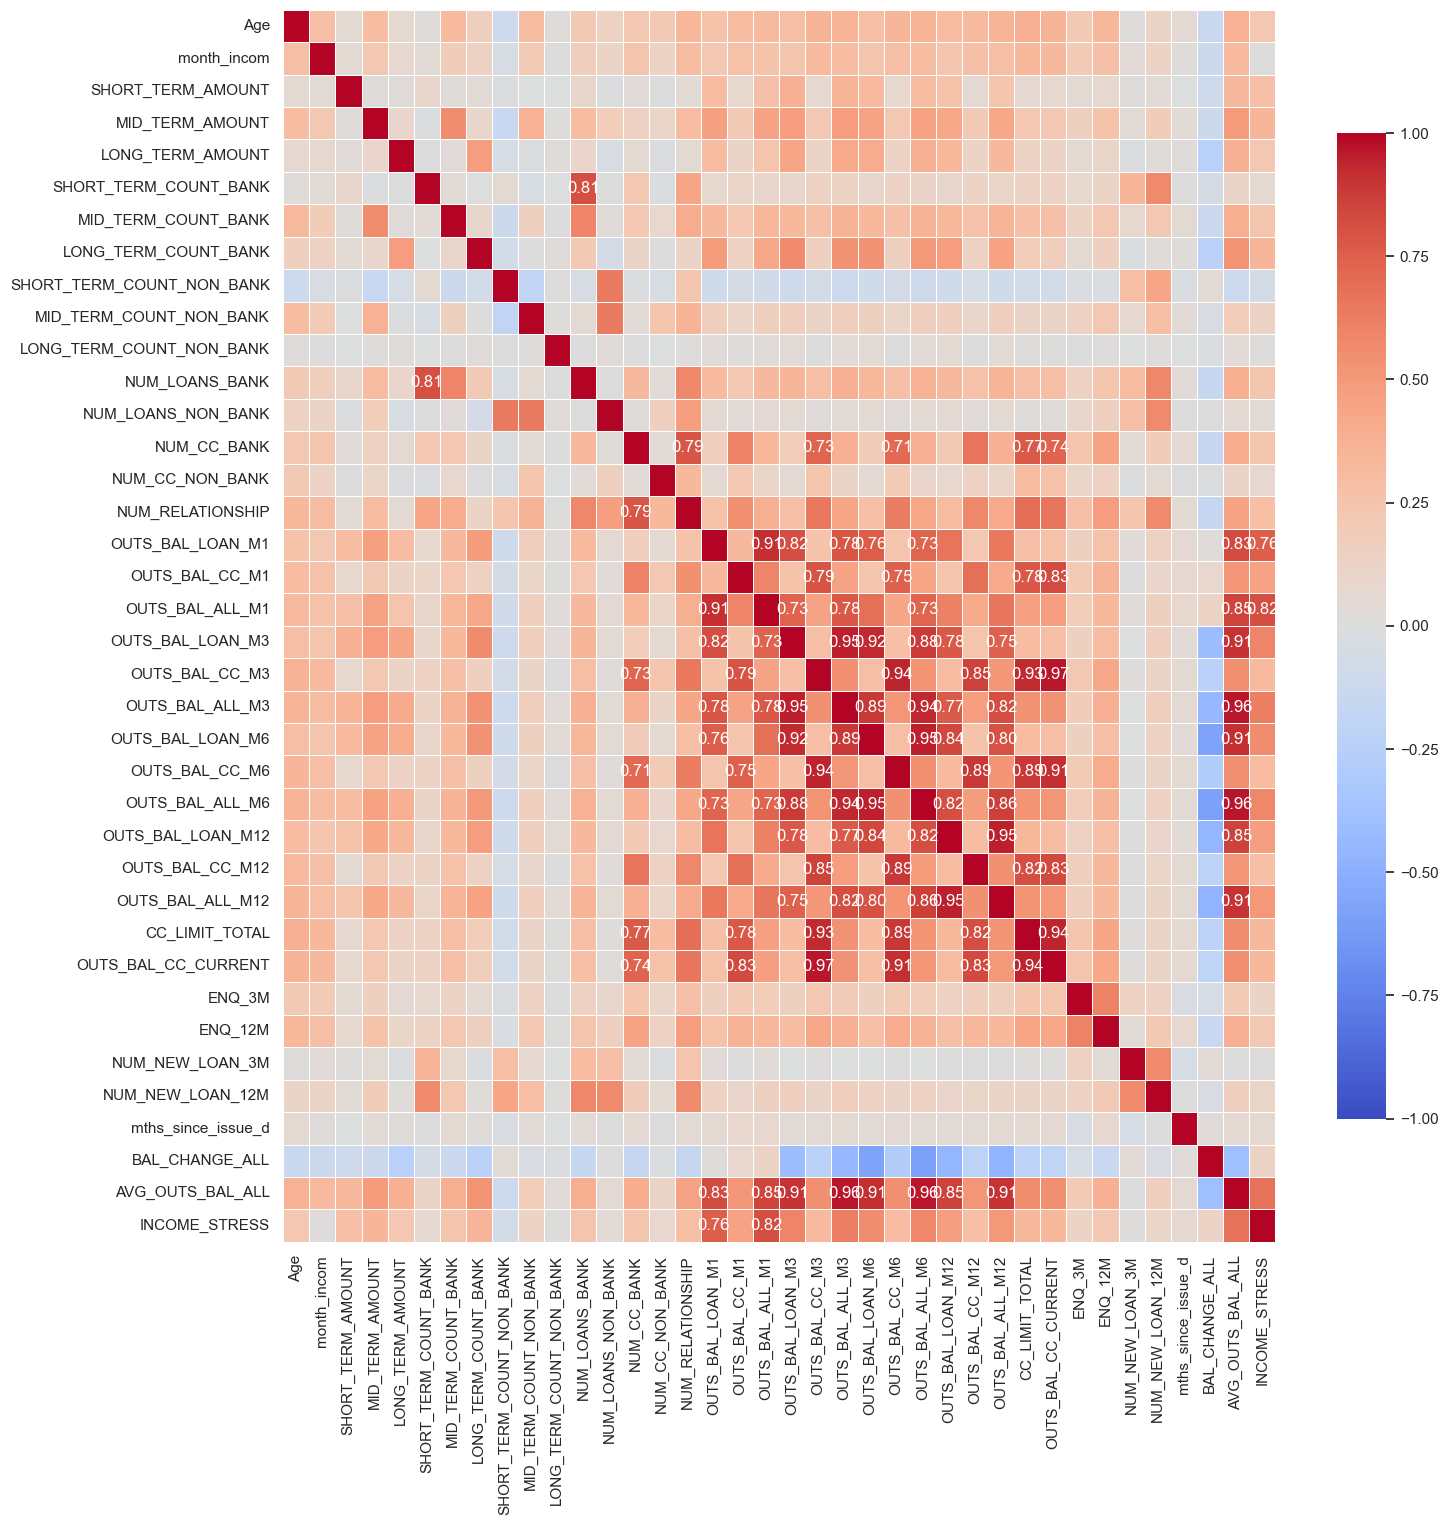

In [126]:
corr = loan_data2_fe.corr(numeric_only=True) #check corr of whold dataset so we use loan_data2_fe

# Create a version of the correlation matrix where values < 0.7 are empty strings
annot_mask = corr.applymap(lambda x: f'{x:.2f}' if 0.7 <= abs(x) < 1 else "")

plt.figure(figsize=(16, 16))

sns.heatmap(
    corr, 
    annot=annot_mask,   # Use our filtered strings for annotations
    fmt="",             # Format must be empty because we pre-formatted the strings
    cmap='coolwarm', 
    linewidths=0.5,
    vmin=-1, vmax=1,    # Ensure the scale is always -1 to 1
    cbar_kws={"shrink": .8}
)
plt.show()

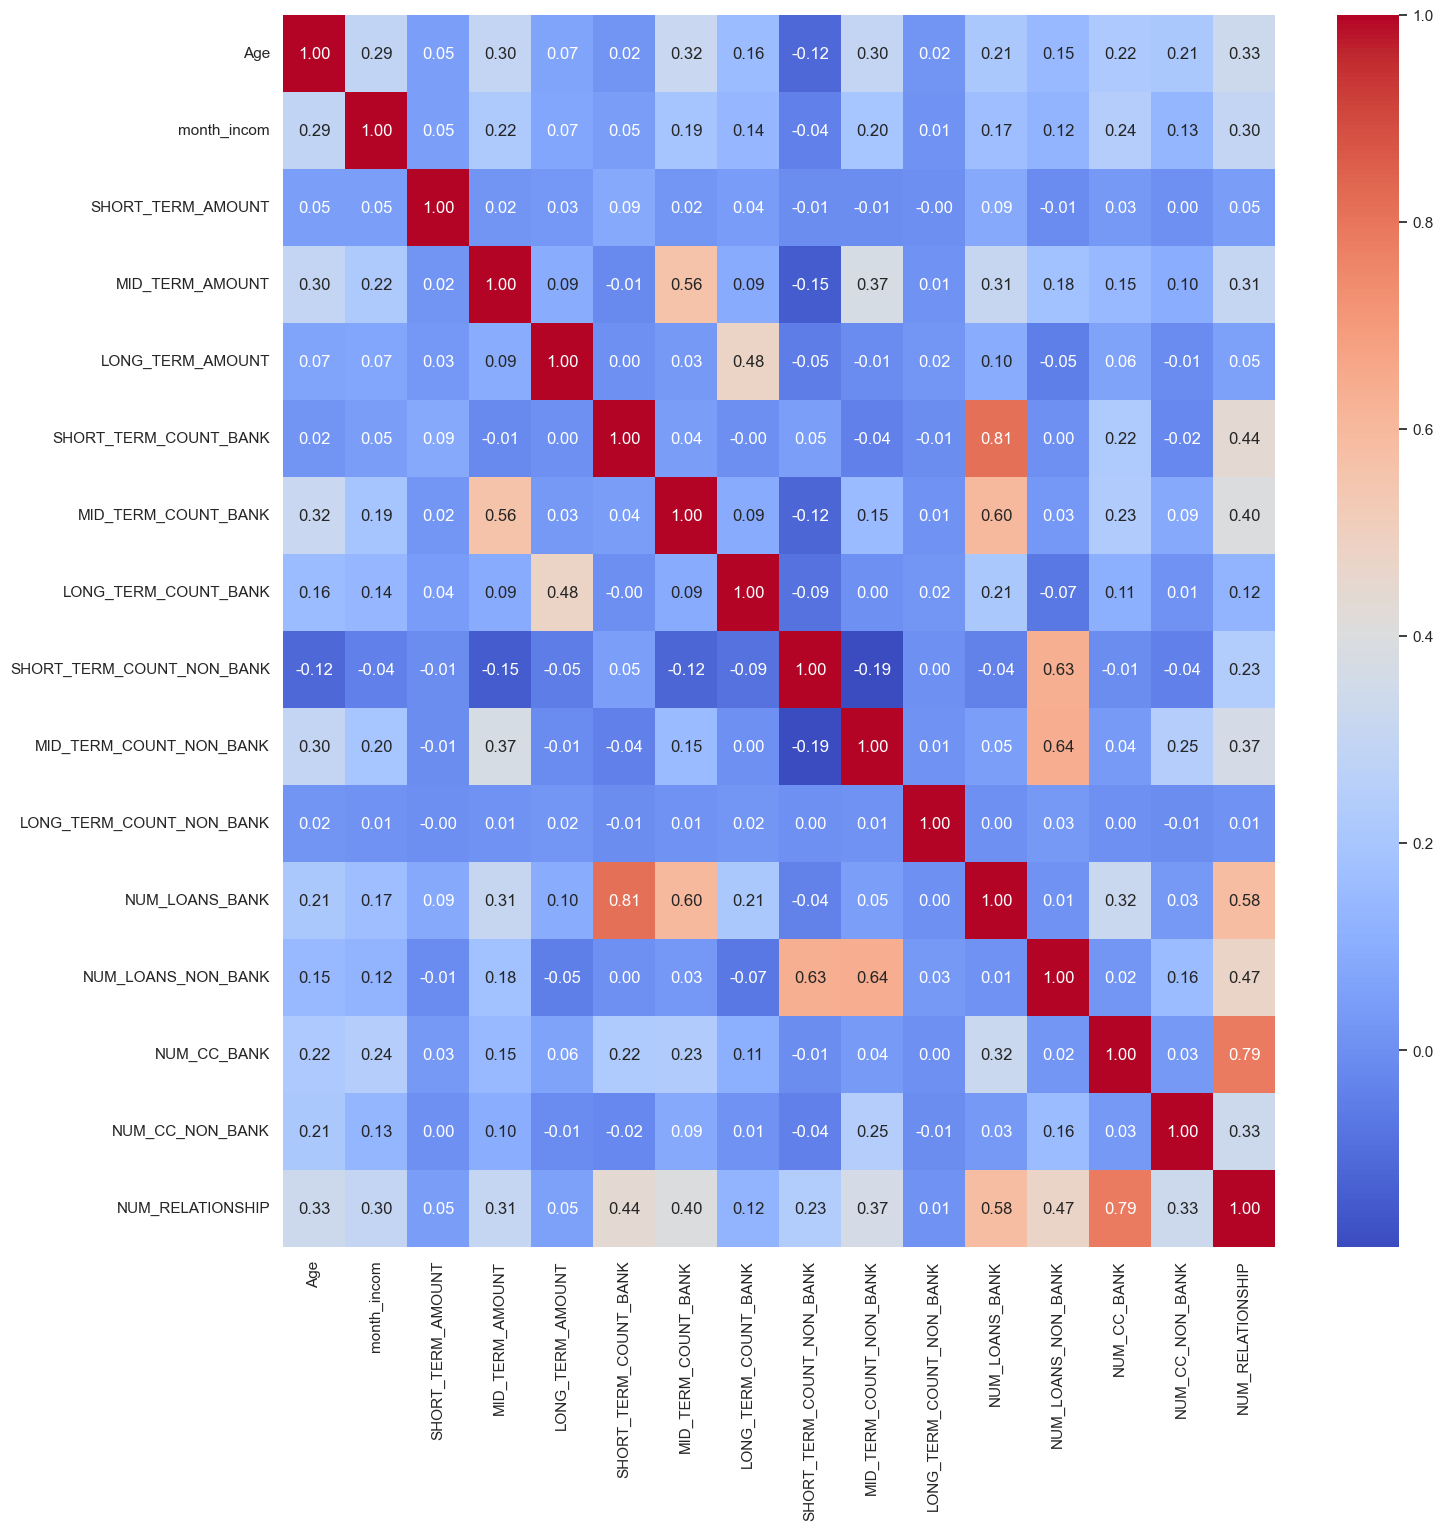

In [127]:
cols = ['Age', 'gender', 'occupation', 'month_incom', 'operating_system',
       'phone_provider', 'SHORT_TERM_AMOUNT', 'MID_TERM_AMOUNT',
       'LONG_TERM_AMOUNT', 'SHORT_TERM_COUNT_BANK', 'MID_TERM_COUNT_BANK',
       'LONG_TERM_COUNT_BANK', 'SHORT_TERM_COUNT_NON_BANK',
       'MID_TERM_COUNT_NON_BANK', 'LONG_TERM_COUNT_NON_BANK', 'NUM_LOANS_BANK',
       'NUM_LOANS_NON_BANK', 'NUM_CC_BANK', 'NUM_CC_NON_BANK',
       'NUM_RELATIONSHIP']

corr = loan_data2_fe[cols].corr(numeric_only=True)

plt.figure(figsize=(16,16))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

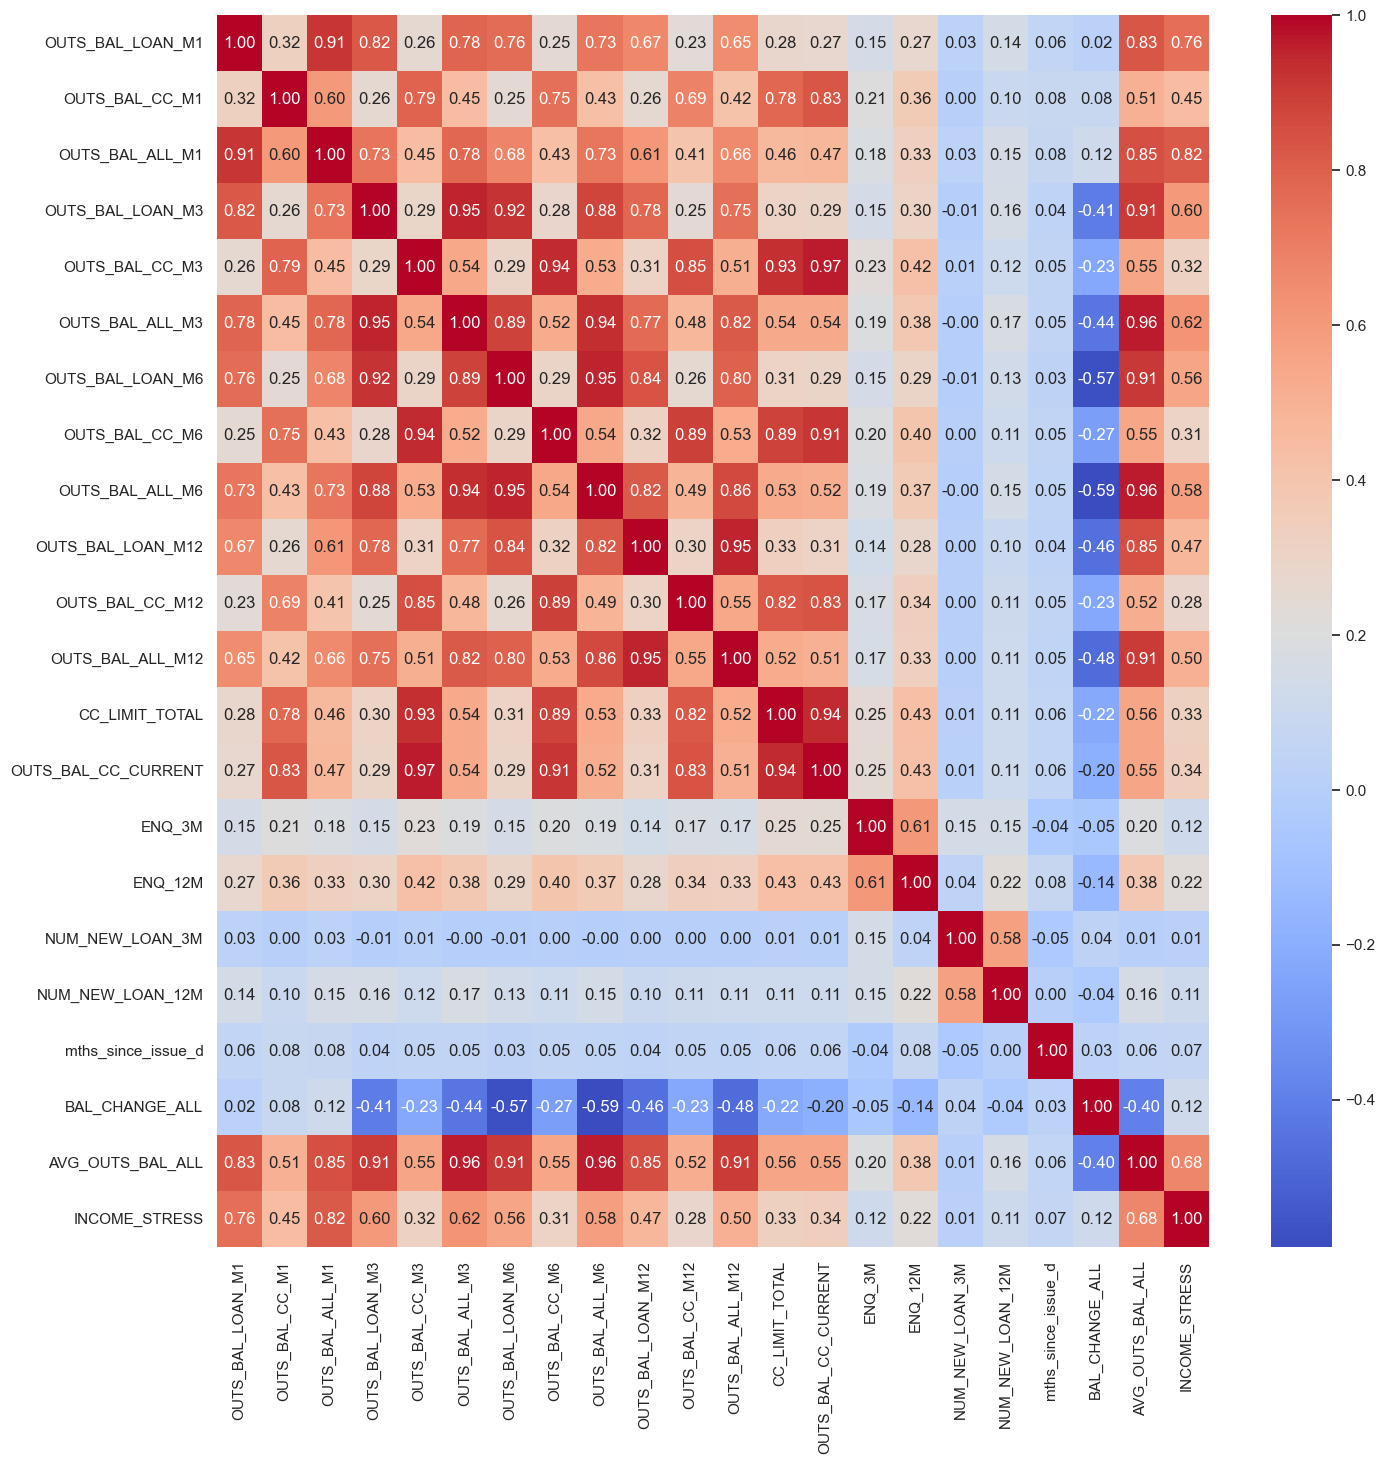

In [128]:
cols =['OUTS_BAL_LOAN_M1', 'OUTS_BAL_CC_M1',
       'OUTS_BAL_ALL_M1', 'OUTS_BAL_LOAN_M3', 'OUTS_BAL_CC_M3',
       'OUTS_BAL_ALL_M3', 'OUTS_BAL_LOAN_M6', 'OUTS_BAL_CC_M6',
       'OUTS_BAL_ALL_M6', 'OUTS_BAL_LOAN_M12', 'OUTS_BAL_CC_M12',
       'OUTS_BAL_ALL_M12', 'CC_LIMIT_TOTAL', 'OUTS_BAL_CC_CURRENT', 'ENQ_3M',
       'ENQ_12M', 'NUM_NEW_LOAN_3M', 'NUM_NEW_LOAN_12M', 'address',
       'mths_since_issue_d', 'BAL_CHANGE_ALL', 'AVG_OUTS_BAL_ALL',
       'INCOME_STRESS']
corr = loan_data2_fe[cols].corr(numeric_only=True)

plt.figure(figsize=(16,16))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [ ]:
#SPLIT DATA

In [129]:
# BEFORE train_test_split
cat_cols = ['gender',
    'occupation',
    'operating_system',
    'phone_provider',
    'address']

for col in cat_cols:
    loan_data2_fe[col] = loan_data2_fe[col].astype('category')

# split AFTER conversion
# X_train, X_test, y_train, y_test = train_test_split(
#     loan_data2, y,
#     test_size=0.2,
#     random_state=42
# )

# split data into train and test datasets, ratio 8/2 
inputs_train, inputs_test, targets_train, targets_test = train_test_split(
    loan_data2_fe, y, test_size=0.2, stratify=y,random_state= 42) 

df_inputs_prepr = inputs_train
df_targets_prepr = targets_train

# print(targets_train.value_counts(normalize=True).mul(100))
# print(targets_test.value_counts(normalize=True).mul(100))

In [130]:
df_inputs_prepr.head()

,Age,gender,occupation,month_incom,operating_system,phone_provider,SHORT_TERM_AMOUNT,MID_TERM_AMOUNT,LONG_TERM_AMOUNT,SHORT_TERM_COUNT_BANK,MID_TERM_COUNT_BANK,LONG_TERM_COUNT_BANK,SHORT_TERM_COUNT_NON_BANK,MID_TERM_COUNT_NON_BANK,LONG_TERM_COUNT_NON_BANK,NUM_LOANS_BANK,NUM_LOANS_NON_BANK,NUM_CC_BANK,NUM_CC_NON_BANK,NUM_RELATIONSHIP,OUTS_BAL_LOAN_M1,OUTS_BAL_CC_M1,OUTS_BAL_ALL_M1,OUTS_BAL_LOAN_M3,OUTS_BAL_CC_M3,OUTS_BAL_ALL_M3,OUTS_BAL_LOAN_M6,OUTS_BAL_CC_M6,OUTS_BAL_ALL_M6,OUTS_BAL_LOAN_M12,OUTS_BAL_CC_M12,OUTS_BAL_ALL_M12,CC_LIMIT_TOTAL,OUTS_BAL_CC_CURRENT,ENQ_3M,ENQ_12M,NUM_NEW_LOAN_3M,NUM_NEW_LOAN_12M,address,mths_since_issue_d,BAL_CHANGE_ALL,AVG_OUTS_BAL_ALL,INCOME_STRESS
7103,33.0,FEMALE,OTHER,17000000.0,IOS,viettel,36,391,0,1,2,0,1,2,0,3,3,2,1,9,425.0,38,463.0,444.0,40.0,484.0,418.0,30.0,448.0,427,0,427.0,40.0,38.0,2,18,1,3,PT,23.0,15.0,455.50,2.723529e-05
7388,28.0,MALE,WORKER,8000000.0,IOS,viettel,26,0,0,1,0,0,0,0,0,1,0,1,1,3,0.0,0,0.0,28.0,57.0,85.0,20.0,0.0,20.0,0,0,0.0,77.0,57.0,4,8,1,2,TB,23.0,-20.0,26.25,0.000000e+00
6044,30.0,MALE,OTHER,13000000.0,ANDROID,viettel,16,0,0,0,0,0,2,0,0,0,2,0,1,3,19.0,10,29.0,22.0,10.0,32.0,0.0,0.0,0.0,0,0,0.0,10.0,10.0,3,4,0,2,HN,23.0,29.0,15.25,2.230769e-06
418,19.0,MALE,WORKER,5000000.0,IOS,mobifone,3,0,0,1,0,0,1,0,0,1,1,0,0,2,2.0,0,2.0,1.0,0.0,1.0,1.0,0.0,1.0,5,0,5.0,0.0,0.0,1,1,1,1,DN,25.0,1.0,2.25,4.000000e-07
4921,20.0,FEMALE,WORKER,9000000.0,0,viettel,19,0,0,2,0,0,1,0,0,2,1,1,0,4,19.0,1,20.0,9.0,1.0,10.0,1.0,2.0,3.0,0,0,0.0,10.0,1.0,1,1,2,3,HN,23.0,17.0,8.25,2.222222e-06


In [131]:
# train
model = LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    importance_type='gain',
    class_weight='balanced',
    verbosity=-1, random_state=42
)

model.fit(df_inputs_prepr , df_targets_prepr)

# feature importance
imp = pd.DataFrame({
    'feature': df_inputs_prepr.columns,
    'importance': model.feature_importances_
})

# sort
imp = imp.sort_values('importance', ascending=False)
imp

,feature,importance
4,operating_system,33525.562197
38,address,9296.119096
3,month_incom,2291.116130
0,Age,1695.064368
40,BAL_CHANGE_ALL,1650.801792
29,OUTS_BAL_LOAN_M12,1584.401994
23,OUTS_BAL_LOAN_M3,1459.021570
17,NUM_CC_BANK,1344.179839
31,OUTS_BAL_ALL_M12,1317.247342
7,MID_TERM_AMOUNT,1242.171161


C:\Users\Admin\anaconda3\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


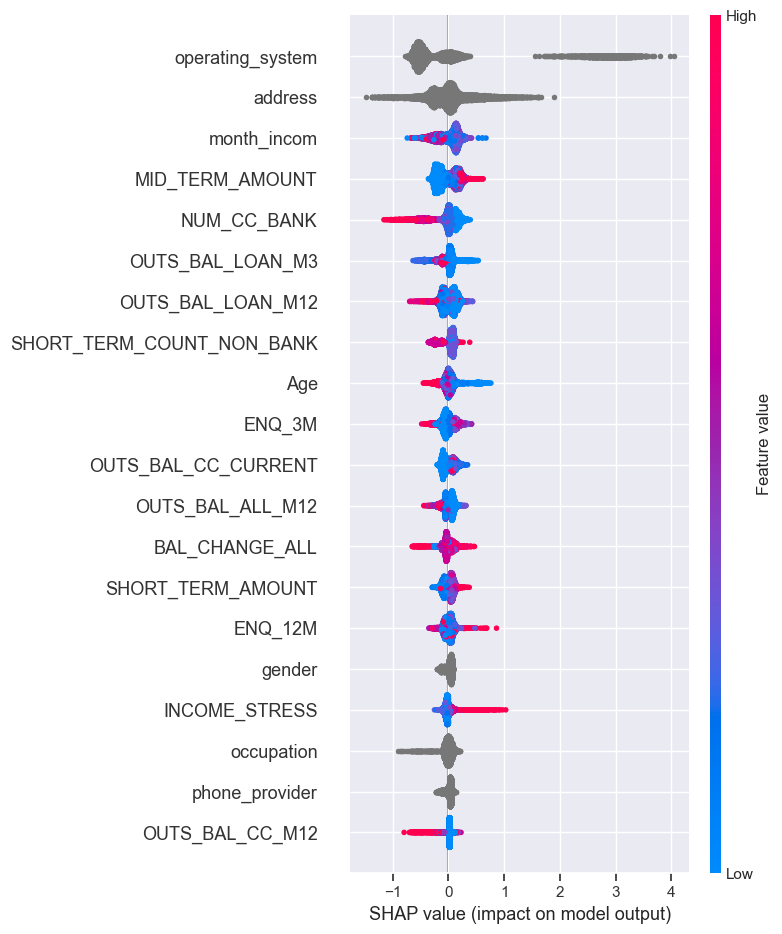

In [137]:
# SHAP explainer
explainer = shap.TreeExplainer(model)

# SHAP values
shap_values = explainer.shap_values(df_inputs_prepr)

# summary plot
shap.summary_plot( shap_values, df_inputs_prepr)

In [138]:
shap_imp = pd.DataFrame({'feature': df_inputs_prepr.columns,'importance': np.abs(shap_values).mean(axis=0)})
shap_imp = shap_imp.sort_values('importance',ascending=False)
shap_imp

,feature,importance
4,operating_system,0.645298
38,address,0.257332
3,month_incom,0.160548
7,MID_TERM_AMOUNT,0.157982
17,NUM_CC_BANK,0.157217
23,OUTS_BAL_LOAN_M3,0.107515
29,OUTS_BAL_LOAN_M12,0.103453
12,SHORT_TERM_COUNT_NON_BANK,0.099979
0,Age,0.092961
34,ENQ_3M,0.091781


In [ ]:
# df_inputs_prepr.columns
# df_inputs_prepr.info()

In [141]:
# func for woe
# WoE function for discrete unordered variables
def woe_discrete(df, discrete_variabe_name, good_bad_variable_df):
    
    '''arguments: a dataframe, a string, and a dataframe. 
   output: a dataframe''' 
    
    df = pd.concat([df[discrete_variabe_name], good_bad_variable_df], axis=1)
    
    # Rename target column to make it clear
    df.columns = [discrete_variabe_name, 'target']
    
    df = pd.concat([df.groupby(df.columns[0], as_index=False)['target'].count(),
                    df.groupby(df.columns[0], as_index=False)['target'].mean()], axis=1)
    
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_bad']  
    
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_bad'] = df['prop_bad'] * df['n_obs']
    df['n_good'] = (1 - df['prop_bad']) * df['n_obs']
    
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    
    epsilon = 1e-10
    df['WoE'] = np.log((df['prop_n_good'] + epsilon) / 
                       (df['prop_n_bad'] + epsilon))
    
    df = df.sort_values(['WoE'])
    df = df.reset_index(drop=True)
    
    df['diff_prop_good'] = df['prop_bad'].diff().abs()      
    df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    
    return df

# Continuous / Ordered variables
def woe_ordered_continuous(df, discrete_variabe_name, good_bad_variable_df):
    
    df = pd.concat([df[discrete_variabe_name], good_bad_variable_df], axis=1)
    
    df = pd.concat([df.groupby(df.columns.values[0], as_index=False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index=False)[df.columns.values[1]].mean()], axis=1)
    
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_bad']     
    
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_bad']  = df['prop_bad'] * df['n_obs']                
    df['n_good'] = (1 - df['prop_bad']) * df['n_obs']           
    
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad']  = df['n_bad'] / df['n_bad'].sum()
    
    epsilon = 1e-10
    df['WoE'] = np.log((df['prop_n_good'] + epsilon) / 
                       (df['prop_n_bad'] + epsilon))
    
    # df = df.sort_values(['WoE'])          # Usually we keep original order for continuous
    # df = df.reset_index(drop=True)
    
    df['diff_prop_good'] = df['prop_bad'].diff().abs()          
    df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    
    return df

In [142]:
# exclude categorical columns
cols = df_inputs_prepr.select_dtypes( exclude=['category', 'object']).columns

# create temporary copy for IV calculation
df_iv = df_inputs_prepr.copy()

# auto binning: if more than 50 unique values, cut into 50 bins
for col in cols:

    if df_iv[col].nunique() > 50: df_iv[col] = pd.cut( df_iv[col],bins=50 )

iv_table = pd.DataFrame([# IV table. # use temporary binned dataframe
    {
        'feature': col,'IV': woe_ordered_continuous( df_iv,  col,  df_targets_prepr )['IV'].iloc[0]
    }
    for col in cols
])

iv_table = iv_table.sort_values('IV', ascending=False)
print(iv_table)

                      feature        IV
20             OUTS_BAL_CC_M3  0.520468
29        OUTS_BAL_CC_CURRENT  0.453454
13                NUM_CC_BANK  0.445091
26            OUTS_BAL_CC_M12  0.445061
35             BAL_CHANGE_ALL  0.440499
23             OUTS_BAL_CC_M6  0.396845
18            OUTS_BAL_ALL_M1  0.386064
28             CC_LIMIT_TOTAL  0.379227
25          OUTS_BAL_LOAN_M12  0.346313
36           AVG_OUTS_BAL_ALL  0.335743
17             OUTS_BAL_CC_M1  0.330989
19           OUTS_BAL_LOAN_M3  0.325243
24            OUTS_BAL_ALL_M6  0.325039
22           OUTS_BAL_LOAN_M6  0.319253
27           OUTS_BAL_ALL_M12  0.292469
21            OUTS_BAL_ALL_M3  0.289817
16           OUTS_BAL_LOAN_M1  0.277725
31                    ENQ_12M  0.178007
15           NUM_RELATIONSHIP  0.177067
3             MID_TERM_AMOUNT  0.150357
2           SHORT_TERM_AMOUNT  0.125129
37              INCOME_STRESS  0.121051
30                     ENQ_3M  0.116804
4            LONG_TERM_AMOUNT  0.079090


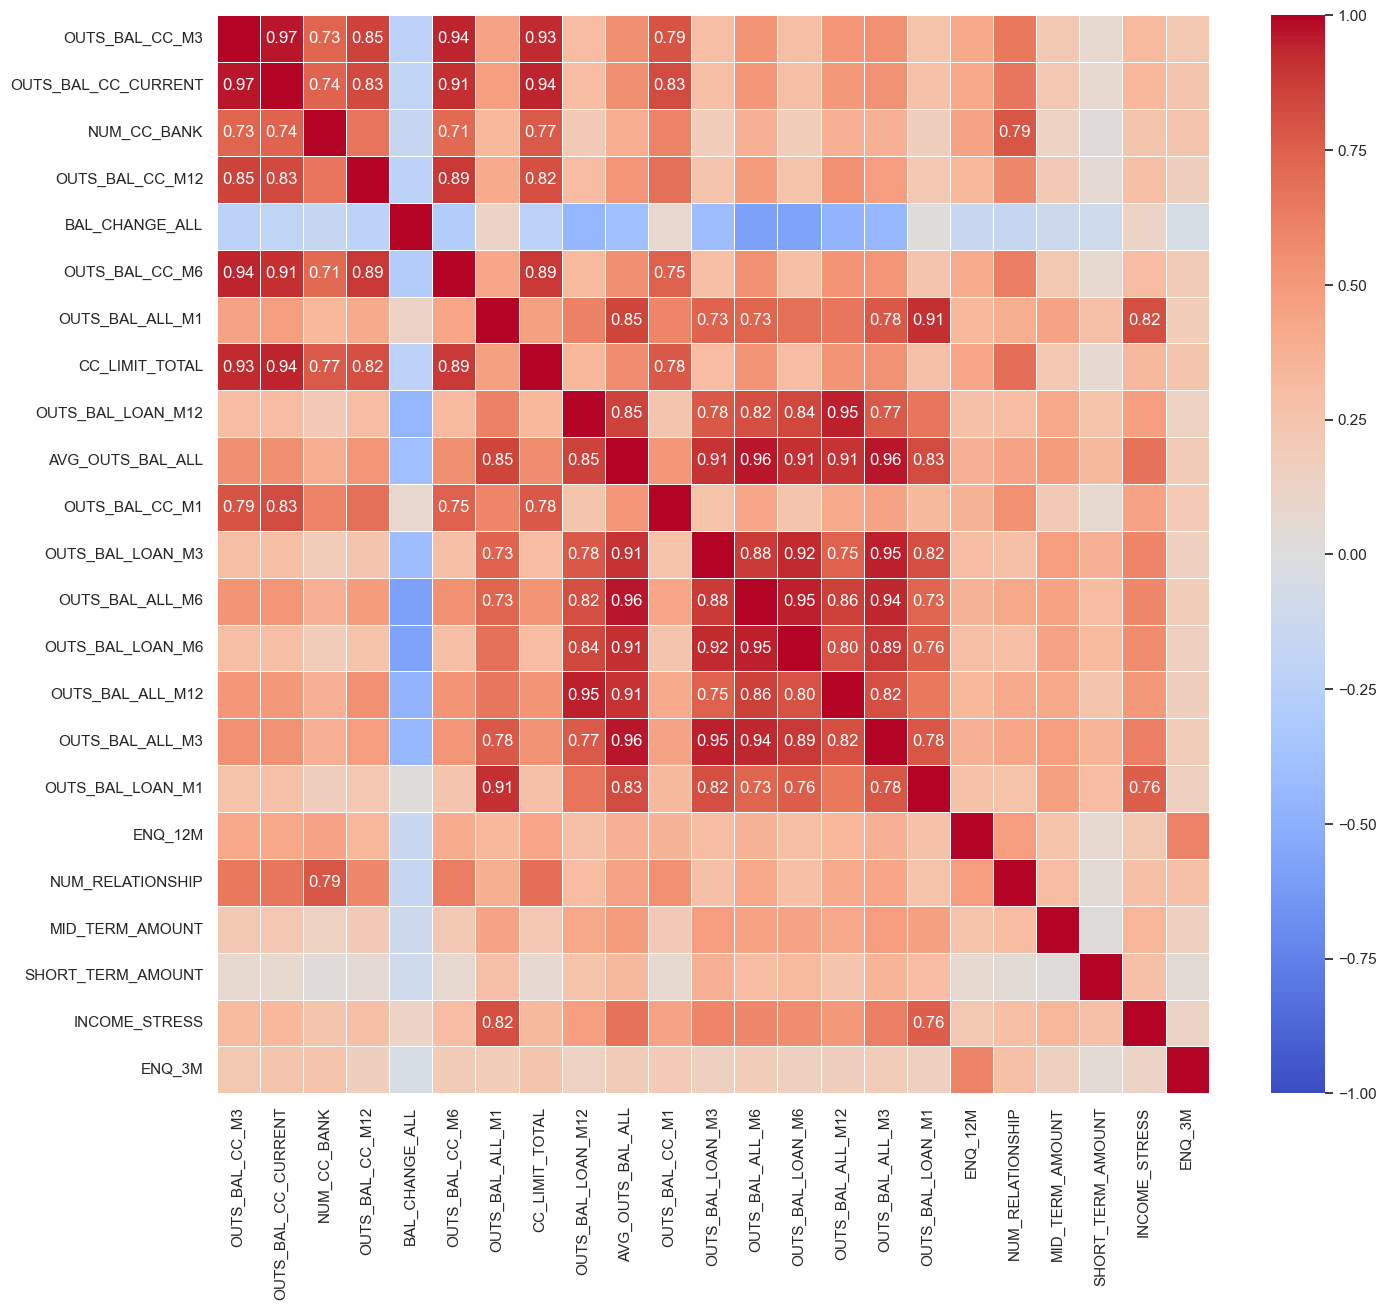

In [143]:
# keep only features with IV >= 0.1
selected_cols = iv_table.loc[
    iv_table['IV'] >= 0.1, 'feature'
].tolist()

# correlation
corr = loan_data2_fe[selected_cols].corr(numeric_only=True)

# show only |corr| >= 0.7
annot_mask = corr.applymap(
    lambda x: f'{x:.2f}' if 0.7 <= abs(x) < 1 else ""
)

plt.figure(figsize=(16,14))

sns.heatmap(
    corr,
    annot=annot_mask,
    fmt="",
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.show() #note that this order is in decresing order of IV so give priority for firsts columns in the selection

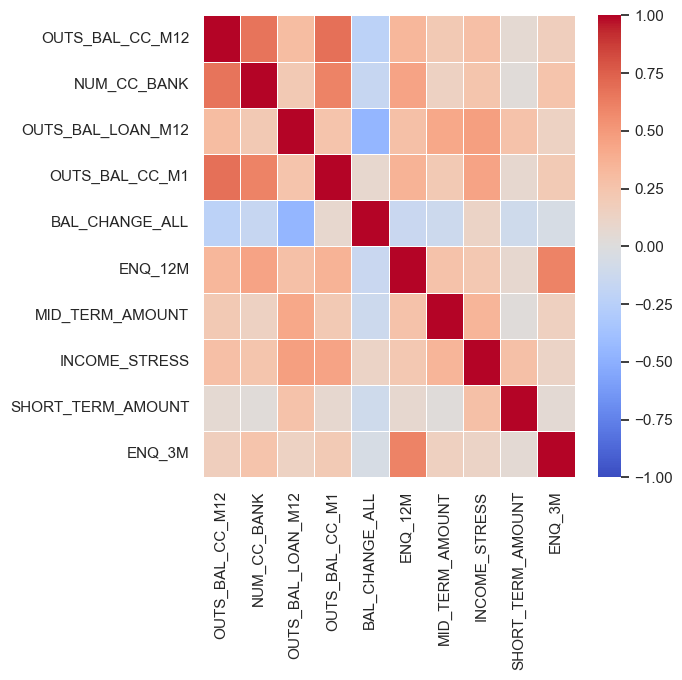

In [144]:
cols = [
    'OUTS_BAL_CC_M12', 
    'NUM_CC_BANK', 
#     'OUTS_BAL_ALL_M1', 
    'OUTS_BAL_LOAN_M12', 
    'OUTS_BAL_CC_M1', 
    'BAL_CHANGE_ALL', 
#     'OUTS_BAL_ALL_M12', 
#     'OUTS_BAL_LOAN_M1', 
    'ENQ_12M', 
    'MID_TERM_AMOUNT', 
    'INCOME_STRESS', 
    'SHORT_TERM_AMOUNT', 
    'ENQ_3M'
]

corr = loan_data2_fe[cols].corr(numeric_only=True)
for col in cols:

    corr = loan_data2_fe[cols].corr(numeric_only=True)

    # show only |corr| >= 0.7
    annot_mask = corr.applymap(
        lambda x: f'{x:.2f}' if 0.7 <= abs(x) < 1 else ""
    )

plt.figure(figsize=(6,6))

sns.heatmap(
    corr,
    annot=annot_mask,
    fmt="",
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.show()

In [ ]:
# i will check woe n bining discrete, thenn continous.
#optional: after that,, try also corr continous variable n run tree model intead of logreg

# imp['feature'].unique()

## discrete

In [ ]:
# We create dummy variables from original independent discrete variables, and save them into a list.
#  naming convention for all variables: original variable name, colon, category name.
dummies_columns = ['occupation','address']

loan_data_dummies = pd.DataFrame()
for col in dummies_columns:
    dummy= pd.get_dummies(df_inputs_prepr[col], prefix = col, prefix_sep = ':')
    loan_data_dummies = pd.concat([loan_data_dummies, dummy ], axis=1)
    
# loan_data_dummies.columns.values #check

#merge dummy columns with the dataset
df_inputs_prepr= pd.concat([df_inputs_prepr,loan_data_dummies],axis = 1)

In [ ]:
df_temp = woe_discrete(df_inputs_prepr, 'occupation',df_targets_prepr)
df_temp

In [ ]:
# dummies for occupation
# FARMER + Business_Households + CASUAL_STAFF 
# WORKER
# OTHER 
# EMPLOYEE +  ENGINEER 
# FREELANCER + STUDENT 
# LAYWER_POLICE_ARMY_JOURNALIST + HOUSE_WIFE + MEDICAL_ENGINEER +  MEDICAL_WORKER #RETIREE 

df_inputs_prepr['occupation:FARMER_Business_Households_CASUAL_STAFF'] = np.where(
    df_inputs_prepr['occupation'].isin(['CASUAL_STAFF', 'FARMER', 'Business_Households']), 1, 0)

df_inputs_prepr['occupation:WORKER'] = np.where(df_inputs_prepr['occupation'] == 'WORKER', 1, 0)
df_inputs_prepr['occupation:OTHER'] = np.where(df_inputs_prepr['occupation']=='OTHER', 1, 0)

df_inputs_prepr['occupation:EMPLOYEE_ENGINEER'] = np.where(
    df_inputs_prepr['occupation'].isin(['EMPLOYEE', 'ENGINEER']), 1, 0)

df_inputs_prepr['occupation:FREELANCER_STUDENT'] = np.where(
    df_inputs_prepr['occupation'].isin(['FREELANCER','STUDENT']), 1, 0)    

df_inputs_prepr['occupation:LPAJ_HOUSE_WIFE_ME_MW_R'] = np.where(
    df_inputs_prepr['occupation'].isin(['LAYWER_POLICE_ARMY_JOURNALIST','HOUSE_WIFE'
                                        'MEDICAL_ENGINEER','RETIREE','MEDICAL_WORKER']), 1, 0)  

In [ ]:
df_temp = woe_discrete(df_inputs_prepr, 'address',df_targets_prepr) 
df_temp 

In [ ]:
# ['ĐB','GL','LD','VL','NT']
# ['BĐ','TG','QB','ĐL','TV','NB','BP','BL','LA']
# ['QN',BG','LĐ','DT','KH','AG',TTH','BT','PY','TB']
# ['HD','HG",PT','BN','DNN', 'DN"]
# ['HB','HY','NA','VP','TH','CT',BD','BRVT','QT','ĐT','LC', 'NĐ','CB']
# ['HCM']
#['KG','ND','TN','LS']
#['HN']
# # rare / unstable categories (merge together)
# ['DL','SL','TQ',"DkN", 'ST','CM','BK','HP','HT']

# ====================== ADDRESS GROUPING ======================

# High risk group (already done)
df_inputs_prepr['address:ĐB_GL_LD_VL_NT'] = sum([
    df_inputs_prepr['address:ĐB'],
    df_inputs_prepr['address:GL'],
    df_inputs_prepr['address:LD'],
    df_inputs_prepr['address:VL'],
    df_inputs_prepr['address:NT']
])

# Medium-high risk
df_inputs_prepr['address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA'] = sum([
    df_inputs_prepr['address:BĐ'], df_inputs_prepr['address:TG'],
    df_inputs_prepr['address:QB'], df_inputs_prepr['address:ĐL'],
    df_inputs_prepr['address:TV'], df_inputs_prepr['address:NB'],
    df_inputs_prepr['address:BP'], df_inputs_prepr['address:BL'],
    df_inputs_prepr['address:LA']
])

# Medium risk group 1
df_inputs_prepr['address:QN_BG_LĐ_DT_KH_AG_TTH_BT_PY_TB'] = sum([
    df_inputs_prepr['address:QN'], df_inputs_prepr['address:BG'],
    df_inputs_prepr['address:LĐ'], df_inputs_prepr['address:DT'],
    df_inputs_prepr['address:KH'], df_inputs_prepr['address:AG'],
    df_inputs_prepr['address:TTH'], df_inputs_prepr['address:BT'],
    df_inputs_prepr['address:PY'], df_inputs_prepr['address:TB']
])

# Medium risk group 2
df_inputs_prepr['address:HD_HG_PT_BN_DNN_DN'] = sum([
    df_inputs_prepr['address:HD'], df_inputs_prepr['address:HG'],
    df_inputs_prepr['address:PT'], df_inputs_prepr['address:BN'],
    df_inputs_prepr['address:DNN'], df_inputs_prepr['address:DN']
])

# Medium-low risk
df_inputs_prepr['address:HB_HY_NA_VP_TH_CT_BD_BRVT_QT_ĐT_LC_NĐ_CB'] = sum([
    df_inputs_prepr['address:HB'], df_inputs_prepr['address:HY'],
    df_inputs_prepr['address:NA'], df_inputs_prepr['address:VP'],
    df_inputs_prepr['address:TH'], df_inputs_prepr['address:CT'],
    df_inputs_prepr['address:BD'], df_inputs_prepr['address:BRVT'],
    df_inputs_prepr['address:QT'], df_inputs_prepr['address:ĐT'],
    df_inputs_prepr['address:LC'], df_inputs_prepr['address:NĐ'],
    df_inputs_prepr['address:CB']
])

# Special groups
df_inputs_prepr['address:HCM'] = df_inputs_prepr['address:HCM']
df_inputs_prepr['address:HN']  = df_inputs_prepr['address:HN']

df_inputs_prepr['address:KG_ND_TN_LS'] = sum([
    df_inputs_prepr['address:KG'], df_inputs_prepr['address:ND'],
    df_inputs_prepr['address:TN'], df_inputs_prepr['address:LS']
])

# Rare / Unstable categories (merge together)
df_inputs_prepr['address:Rare'] = sum([
    df_inputs_prepr['address:DL'], df_inputs_prepr['address:SL'],
    df_inputs_prepr['address:TQ'], df_inputs_prepr['address:DkN'],
    df_inputs_prepr['address:ST'], df_inputs_prepr['address:CM'],
    df_inputs_prepr['address:BK'], df_inputs_prepr['address:HP'],
    df_inputs_prepr['address:HT']
])

# df_inputs_prepr.head()

## continous

In [1976]:
df_temp = woe_ordered_continuous ( df_inputs_prepr, 'NUM_CC_BANK', df_targets_prepr)
df_temp

,NUM_CC_BANK,n_obs,prop_bad,prop_n_obs,n_bad,n_good,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0,3768,0.126062,0.420583,475.0,3293.0,0.404844,0.575758,-0.352185,NaN,NaN,0.445091
1,1,2713,0.078511,0.302824,213.0,2500.0,0.307352,0.258182,0.174329,0.047551,0.526514,0.445091
2,2,1104,0.071558,0.123228,79.0,1025.0,0.126014,0.095758,0.274575,0.006953,0.100246,0.445091
3,3,567,0.047619,0.063288,27.0,540.0,0.066388,0.032727,0.707308,0.023939,0.432732,0.445091
4,4,284,0.042254,0.031700,12.0,272.0,0.033440,0.014545,0.832471,0.005366,0.125163,0.445091
5,5,198,0.050505,0.022101,10.0,188.0,0.023113,0.012121,0.645432,0.008252,0.187039,0.445091
6,6,127,0.047244,0.014176,6.0,121.0,0.014876,0.007273,0.715606,0.003261,0.070174,0.445091
7,7,89,0.000000,0.009934,0.0,89.0,0.010942,0.000000,18.510679,0.047244,17.795073,0.445091
8,8,50,0.040000,0.005581,2.0,48.0,0.005901,0.002424,0.889629,0.040000,17.621050,0.445091
9,9,20,0.000000,0.002232,0.0,20.0,0.002459,0.000000,17.017775,0.040000,16.128146,0.445091


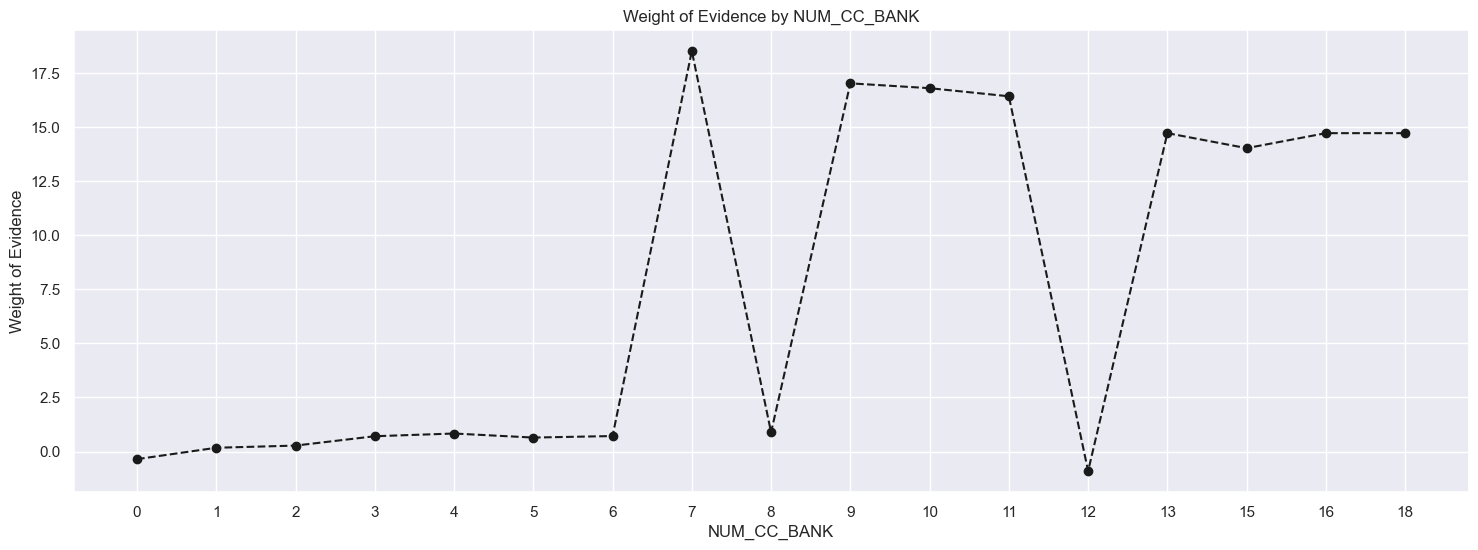

In [1977]:
plot_by_woe(df_temp)

In [1921]:
# '0' will be the reference category
df_inputs_prepr['NUM_CC_BANK:0'] = np.where(df_inputs_prepr['NUM_CC_BANK'].isin([0]), 1, 0)
df_inputs_prepr['NUM_CC_BANK:1'] = np.where(df_inputs_prepr['NUM_CC_BANK'].isin([1]), 1, 0)
df_inputs_prepr['NUM_CC_BANK:2'] = np.where(df_inputs_prepr['NUM_CC_BANK'].isin([2]), 1, 0)
df_inputs_prepr['NUM_CC_BANK:3-4'] = np.where(df_inputs_prepr['NUM_CC_BANK'].isin(range(3, 5)), 1, 0)
df_inputs_prepr['NUM_CC_BANK:5-8'] = np.where(df_inputs_prepr['NUM_CC_BANK'].isin(range(5, 9)), 1, 0)
df_inputs_prepr['NUM_CC_BANK:9-18'] = np.where(df_inputs_prepr['NUM_CC_BANK'].isin(range(9, 19)), 1, 0)

In [1978]:
df_temp = woe_ordered_continuous (df_inputs_prepr, 'ENQ_3M',df_targets_prepr)
df_temp

,ENQ_3M,n_obs,prop_bad,prop_n_obs,n_bad,n_good,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,1,3610,0.080332,0.402947,290.0,3320.0,0.408163,0.351515,0.149414,NaN,NaN,0.116804
1,2,2366,0.089180,0.264092,211.0,2155.0,0.264937,0.255758,0.035263,0.008848,0.114151,0.116804
2,3,1102,0.126134,0.123005,139.0,963.0,0.118392,0.168485,-0.352845,0.036954,0.388108,0.116804
3,4,690,0.100000,0.077018,69.0,621.0,0.076346,0.083636,-0.091200,0.026134,0.261645,0.116804
4,5,453,0.116998,0.050564,53.0,400.0,0.049176,0.064242,-0.267252,0.016998,0.176052,0.116804
5,6,284,0.070423,0.031700,20.0,264.0,0.032456,0.024242,0.291792,0.046575,0.559044,0.116804
6,7,203,0.113300,0.022659,23.0,180.0,0.022129,0.027879,-0.230962,0.042878,0.522754,0.116804
7,8,94,0.085106,0.010492,8.0,86.0,0.010573,0.009697,0.086481,0.028194,0.317443,0.116804
8,9,70,0.085714,0.007813,6.0,64.0,0.007868,0.007273,0.078699,0.000608,0.007782,0.116804
9,10,32,0.093750,0.003572,3.0,29.0,0.003565,0.003636,-0.019741,0.008036,0.098440,0.116804


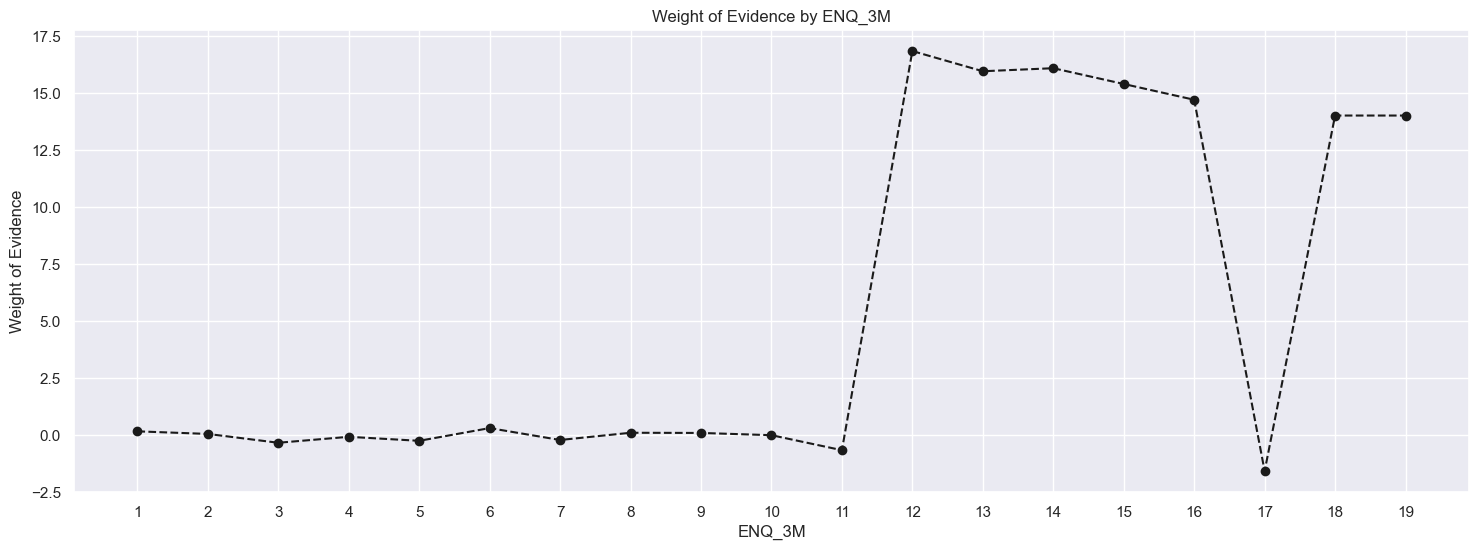

In [1979]:
plot_by_woe(df_temp)

In [1980]:
# # # '1' will be the reference category
df_inputs_prepr['ENQ_3M:1'] = np.where(df_inputs_prepr['ENQ_3M'].isin([1]), 1, 0)
df_inputs_prepr['ENQ_3M:2'] = np.where(df_inputs_prepr['ENQ_3M'].isin([2]), 1, 0)
df_inputs_prepr['ENQ_3M:3'] = np.where(df_inputs_prepr['ENQ_3M'].isin([3]), 1, 0)
df_inputs_prepr['ENQ_3M:4-5'] = np.where(df_inputs_prepr['ENQ_3M'].isin(range(4, 6)), 1, 0)
df_inputs_prepr['ENQ_3M:6-19'] = np.where(df_inputs_prepr['ENQ_3M'].isin(range(6, 20)), 1, 0)

In [1981]:
df_temp = woe_ordered_continuous (df_iv, 'ENQ_12M',df_targets_prepr)
df_temp

,ENQ_12M,n_obs,prop_bad,prop_n_obs,n_bad,n_good,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(0.931, 2.38]",3522,0.090006,0.393124,317.0,3205.0,0.394025,0.384242,0.025141,NaN,NaN,0.178007
1,"(2.38, 3.76]",1168,0.107021,0.130372,125.0,1043.0,0.128227,0.151515,-0.166882,0.017015,0.192023,0.178007
2,"(3.76, 5.14]",1380,0.109420,0.154035,151.0,1229.0,0.151094,0.183030,-0.191748,0.002400,0.024866,0.178007
3,"(5.14, 6.52]",469,0.083156,0.052350,39.0,430.0,0.052865,0.047273,0.111799,0.026265,0.303547,0.178007
4,"(6.52, 7.9]",403,0.119107,0.044983,48.0,355.0,0.043644,0.058182,-0.287508,0.035951,0.399307,0.178007
5,"(7.9, 9.28]",584,0.070205,0.065186,41.0,543.0,0.066757,0.049697,0.295113,0.048901,0.582620,0.178007
6,"(9.28, 10.66]",208,0.086538,0.023217,18.0,190.0,0.023359,0.021818,0.068228,0.016333,0.226885,0.178007
7,"(10.66, 12.04]",336,0.077381,0.037504,26.0,310.0,0.038112,0.031515,0.190051,0.009158,0.121823,0.178007
8,"(12.04, 13.42]",141,0.049645,0.015738,7.0,134.0,0.016474,0.008485,0.663505,0.027736,0.473454,0.178007
9,"(13.42, 14.8]",79,0.075949,0.008818,6.0,73.0,0.008975,0.007273,0.210275,0.026304,0.453230,0.178007


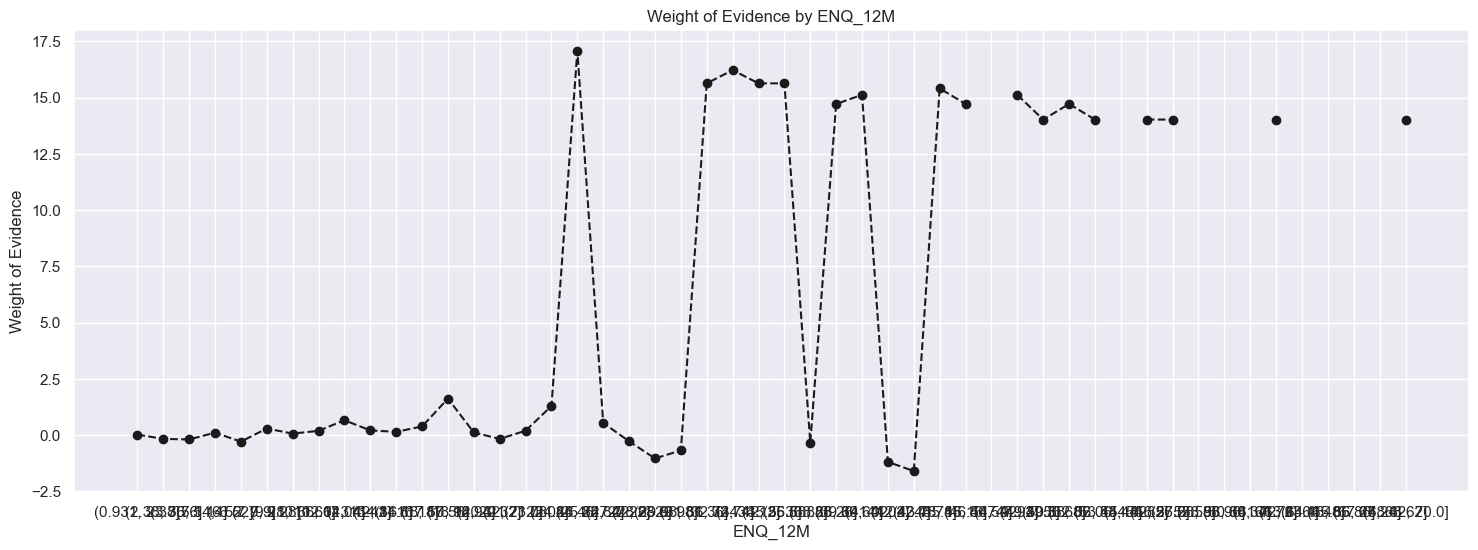

In [1982]:
plot_by_woe(df_temp)

In [1925]:
# use original numeric variable
x = df_inputs_prepr['ENQ_12M']

df_inputs_prepr['ENQ_12M:<=2.38']   = np.where(x <= 2.38, 1, 0)
df_inputs_prepr['ENQ_12M:2.38-3.76'] = np.where((x > 2.38) & (x <= 3.76), 1, 0)
df_inputs_prepr['ENQ_12M:3.76-5.14'] = np.where((x > 3.76) & (x <= 5.14), 1, 0)
df_inputs_prepr['ENQ_12M:5.14-7.9']   = np.where((x > 5.14) & (x <= 7.9), 1, 0)
df_inputs_prepr['ENQ_12M:7.9-12.04']  = np.where((x > 7.9) & (x <= 12.04), 1, 0)
df_inputs_prepr['ENQ_12M:12.04-18.94'] = np.where((x > 12.04) & (x <= 18.94), 1, 0)
df_inputs_prepr['ENQ_12M:>18.94']     = np.where(x > 18.94, 1, 0)

In [1985]:
df_temp = woe_ordered_continuous( df_iv,'OUTS_BAL_CC_M12',df_targets_prepr)
df_temp

,OUTS_BAL_CC_M12,n_obs,prop_bad,prop_n_obs,n_bad,n_good,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.202, 4.04]",6497,0.102047,0.725193,663.0,5834.0,0.717236,0.803636,-0.113742,NaN,NaN,0.445061
1,"(4.04, 8.08]",277,0.064982,0.030919,18.0,259.0,0.031842,0.021818,0.378032,0.037065,0.491773,0.445061
2,"(8.08, 12.12]",323,0.074303,0.036053,24.0,299.0,0.036759,0.029091,0.233965,0.009321,0.144067,0.445061
3,"(12.12, 16.16]",198,0.080808,0.022101,16.0,182.0,0.022375,0.019394,0.142993,0.006505,0.090972,0.445061
4,"(16.16, 20.2]",229,0.078603,0.025561,18.0,211.0,0.025940,0.021818,0.173062,0.002205,0.030068,0.445061
5,"(20.2, 24.24]",138,0.101449,0.015404,14.0,124.0,0.015245,0.016970,-0.107200,0.022847,0.280262,0.445061
6,"(24.24, 28.28]",117,0.059829,0.013059,7.0,110.0,0.013523,0.008485,0.466146,0.041620,0.573346,0.445061
7,"(28.28, 32.32]",142,0.070423,0.015850,10.0,132.0,0.016228,0.012121,0.291792,0.010593,0.174353,0.445061
8,"(32.32, 36.36]",79,0.050633,0.008818,4.0,75.0,0.009221,0.004848,0.642769,0.019790,0.350977,0.445061
9,"(36.36, 40.4]",61,0.032787,0.006809,2.0,59.0,0.007254,0.002424,1.095966,0.017846,0.453196,0.445061


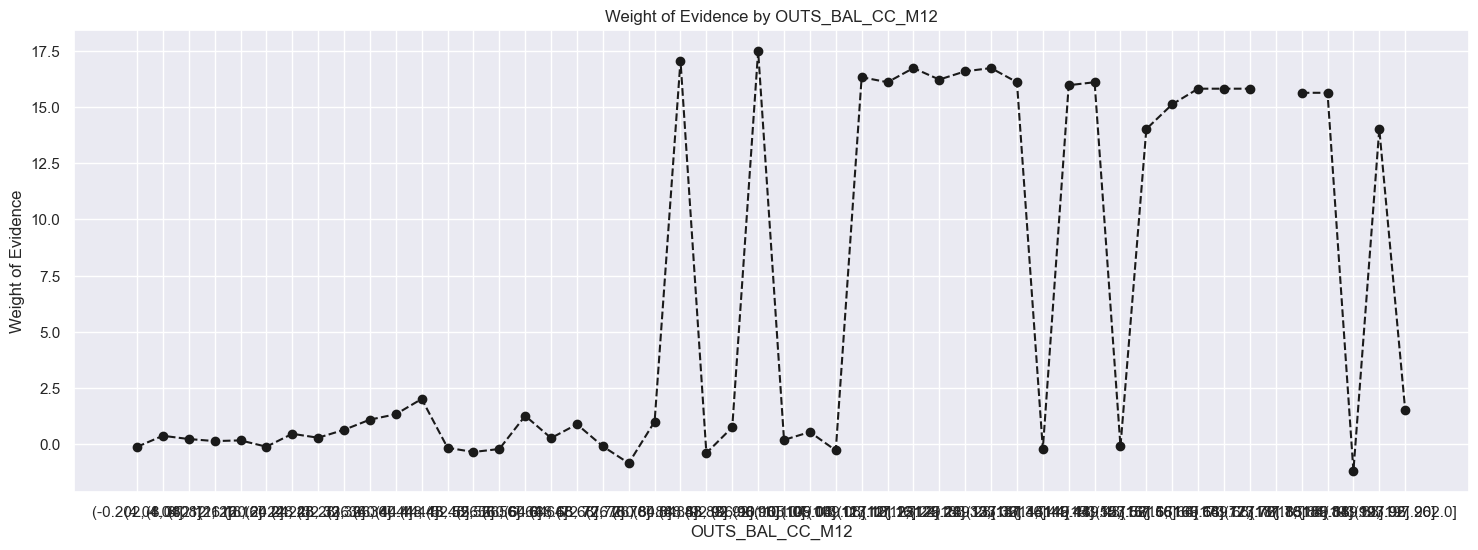

In [1986]:
plot_by_woe(df_temp)

In [1927]:
x = df_inputs_prepr['OUTS_BAL_CC_M12']

df_inputs_prepr['OUTS_BAL_CC_M12:<=4.04']     = np.where(x <= 4.04, 1, 0)                    
df_inputs_prepr['OUTS_BAL_CC_M12:4.04-20.2']  = np.where((x > 4.04) & (x <= 20.2), 1, 0)     
df_inputs_prepr['OUTS_BAL_CC_M12:20.2-36.36']   = np.where((x > 20.2) & (x <= 36.36), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M12:36.36-52.52']   = np.where((x > 36.36) & (x <= 52.52), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M12:52.52-80.8']    = np.where((x > 52.52) & (x <= 80.8), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M12:>80.8']         = np.where(x > 80.8, 1, 0)
# df_inputs_prepr['OUTS_BAL_CC_M12:>55.84'] #check

In [1928]:
# df_inputs_prepr['OUTS_BAL_LOAN_M12'].describe()

In [1987]:
df_temp = woe_ordered_continuous( df_iv,'OUTS_BAL_LOAN_M12',df_targets_prepr)
df_temp

,OUTS_BAL_LOAN_M12,n_obs,prop_bad,prop_n_obs,n_bad,n_good,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.866, 17.32]",6131,0.098190,0.684340,602.0,5529.0,0.679739,0.729697,-0.070920,NaN,NaN,0.346313
1,"(17.32, 34.64]",890,0.086517,0.099341,77.0,813.0,0.099951,0.093333,0.068501,0.011673,0.139421,0.346313
2,"(34.64, 51.96]",483,0.097308,0.053912,47.0,436.0,0.053602,0.056970,-0.060930,0.010792,0.129431,0.346313
3,"(51.96, 69.28]",356,0.087079,0.039737,31.0,325.0,0.039956,0.037576,0.061413,0.010230,0.122343,0.346313
4,"(69.28, 86.6]",243,0.074074,0.027124,18.0,225.0,0.027662,0.021818,0.237304,0.013005,0.175891,0.346313
5,"(86.6, 103.92]",162,0.080247,0.018082,13.0,149.0,0.018318,0.015758,0.150572,0.006173,0.086732,0.346313
6,"(103.92, 121.24]",116,0.034483,0.012948,4.0,112.0,0.013769,0.004848,1.043780,0.045764,0.893208,0.346313
7,"(121.24, 138.56]",76,0.013158,0.008483,1.0,75.0,0.009221,0.001212,2.029063,0.021325,0.985284,0.346313
8,"(138.56, 155.88]",55,0.054545,0.006139,3.0,52.0,0.006393,0.003636,0.564207,0.041388,1.464857,0.346313
9,"(155.88, 173.2]",50,0.020000,0.005581,1.0,49.0,0.006024,0.001212,1.603396,0.034545,1.039189,0.346313


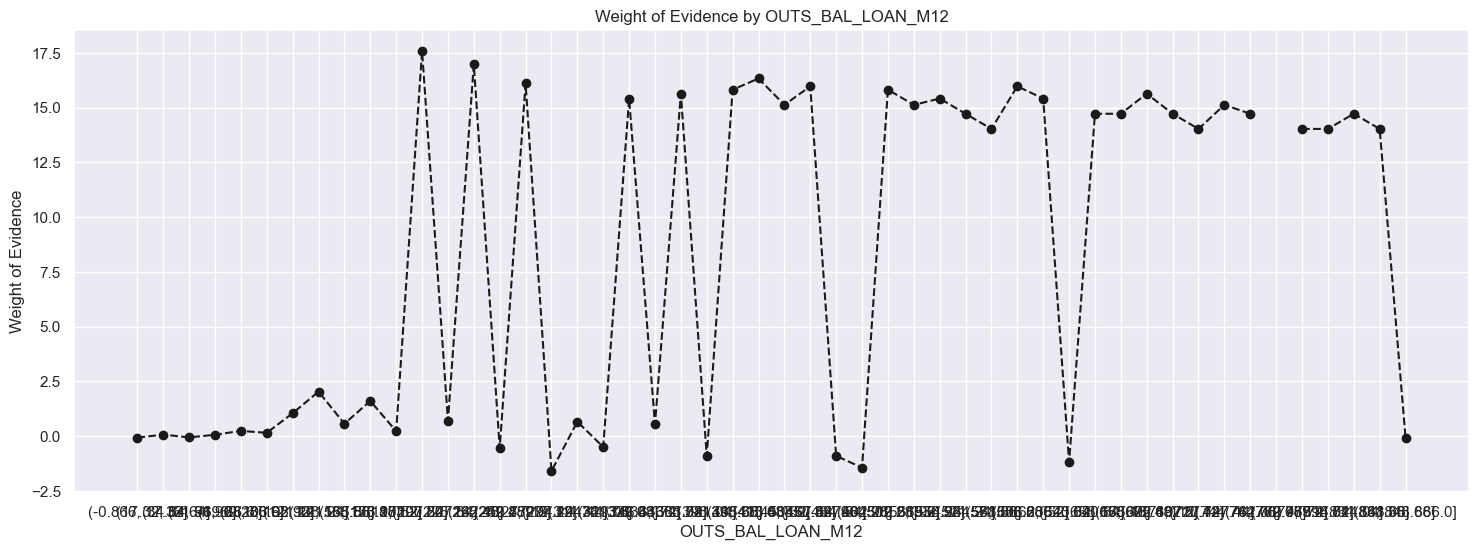

In [1988]:
plot_by_woe(df_temp)

In [1930]:
x = df_inputs_prepr['OUTS_BAL_LOAN_M12']

df_inputs_prepr['OUTS_BAL_LOAN_M12:<=17.32']       = np.where(x <= 17.32, 1, 0)
df_inputs_prepr['OUTS_BAL_LOAN_M12:17.32-51.96']   = np.where((x > 17.32) & (x <= 51.96), 1, 0)
df_inputs_prepr['OUTS_BAL_LOAN_M12:51.96-103.92']  = np.where((x > 51.96) & (x <= 103.92), 1, 0)
df_inputs_prepr['OUTS_BAL_LOAN_M12:103.92-173.2']  = np.where((x > 103.92) & (x <= 173.2), 1, 0)
df_inputs_prepr['OUTS_BAL_LOAN_M12:173.2-277.12']  = np.where((x > 173.2) & (x <= 277.12), 1, 0)
df_inputs_prepr['OUTS_BAL_LOAN_M12:>277.12']       = np.where(x > 277.12, 1, 0)

In [1989]:
df_temp = woe_ordered_continuous ( df_iv,'OUTS_BAL_CC_M1' , df_targets_prepr)
df_temp

,OUTS_BAL_CC_M1,n_obs,prop_bad,prop_n_obs,n_bad,n_good,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.221, 4.42]",5576,0.093615,0.622391,522.0,5054.0,0.621343,0.632727,-0.018157,NaN,NaN,0.330989
1,"(4.42, 8.84]",354,0.062147,0.039513,22.0,332.0,0.040816,0.026667,0.425668,0.031469,0.443825,0.330989
2,"(8.84, 13.26]",435,0.085057,0.048555,37.0,398.0,0.048930,0.044848,0.087109,0.022911,0.338558,0.330989
3,"(13.26, 17.68]",260,0.123077,0.029021,32.0,228.0,0.028030,0.038788,-0.324815,0.038019,0.411924,0.330989
4,"(17.68, 22.1]",333,0.141141,0.037169,47.0,286.0,0.035161,0.056970,-0.482580,0.018064,0.157766,0.330989
5,"(22.1, 26.52]",207,0.072464,0.023105,15.0,192.0,0.023605,0.018182,0.261020,0.068677,0.743601,0.330989
6,"(26.52, 30.94]",181,0.071823,0.020203,13.0,168.0,0.020654,0.015758,0.270590,0.000641,0.009569,0.330989
7,"(30.94, 35.36]",193,0.113990,0.021543,22.0,171.0,0.021023,0.026667,-0.237804,0.042166,0.508394,0.330989
8,"(35.36, 39.78]",119,0.075630,0.013283,9.0,110.0,0.013523,0.010909,0.214831,0.038359,0.452635,0.330989
9,"(39.78, 44.2]",124,0.137097,0.013841,17.0,107.0,0.013155,0.020606,-0.448809,0.061467,0.663640,0.330989


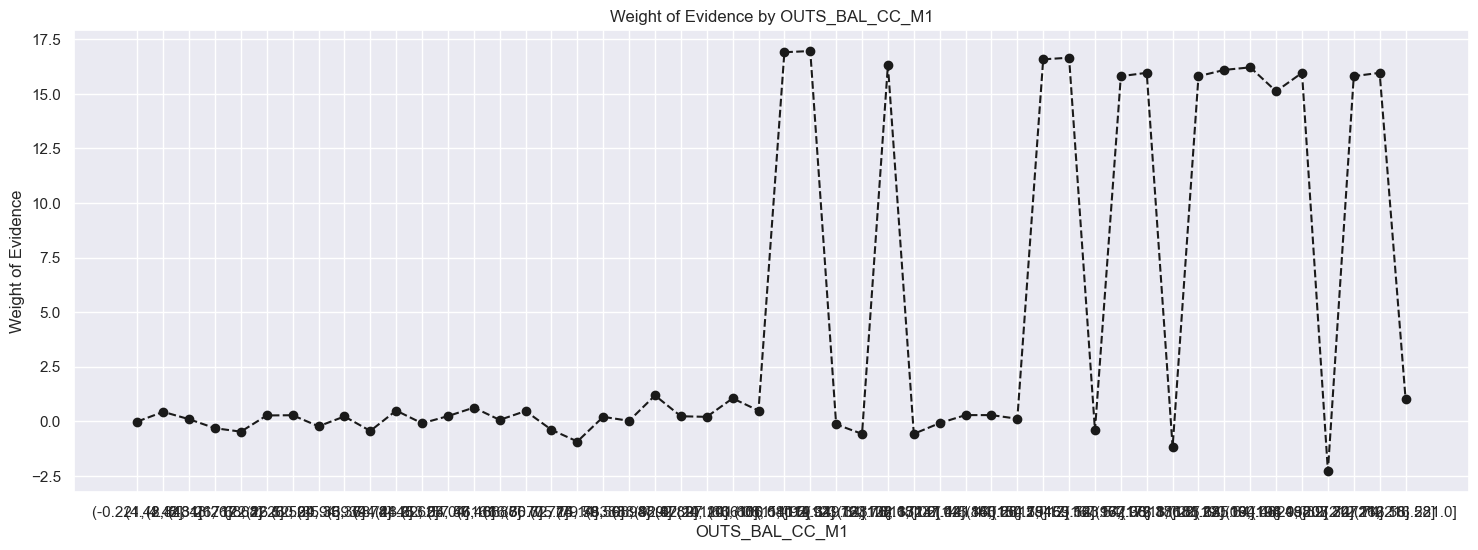

In [1990]:
plot_by_woe(df_temp)

In [1932]:
x = df_inputs_prepr['OUTS_BAL_CC_M1']

df_inputs_prepr['OUTS_BAL_CC_M1:<=4.42']       = np.where(x <= 4.42, 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M1:4.42-17.68']   = np.where((x > 4.42) & (x <= 17.68), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M1:17.68-35.36']   = np.where((x > 17.68) & (x <= 35.36), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M1:35.36-70.72']   = np.where((x > 35.36) & (x <= 70.72), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M1:70.72-150.28']  = np.where((x > 70.72) & (x <= 150.28), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M1:>150.28']       = np.where(x > 150.28, 1, 0)

In [1991]:
df_temp = woe_ordered_continuous ( df_iv,'SHORT_TERM_AMOUNT' , df_targets_prepr)
df_temp

,SHORT_TERM_AMOUNT,n_obs,prop_bad,prop_n_obs,n_bad,n_good,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-15.004, 300.08]",8862,0.091966,0.989173,815.0,8047.0,0.989304,0.987879,0.001442,NaN,NaN,0.125129
1,"(300.08, 600.16]",30,0.166667,0.003349,5.0,25.0,0.003074,0.006061,-0.678987,0.074701,0.680429,0.125129
2,"(600.16, 900.24]",8,0.125000,0.000893,1.0,7.0,0.000861,0.001212,-0.342515,0.041667,0.336472,0.125129
3,"(900.24, 1200.32]",13,0.076923,0.001451,1.0,12.0,0.001475,0.001212,0.196482,0.048077,0.538996,0.125129
4,"(1200.32, 1500.4]",10,0.000000,0.001116,0.0,10.0,0.001229,0.000000,16.324628,0.076923,16.128146,0.125129
5,"(1500.4, 1800.48]",11,0.000000,0.001228,0.0,11.0,0.001352,0.000000,16.419938,0.000000,0.095310,0.125129
6,"(1800.48, 2100.56]",4,0.000000,0.000446,0.0,4.0,0.000492,0.000000,15.408337,0.000000,1.011601,0.125129
7,"(2100.56, 2400.64]",2,0.000000,0.000223,0.0,2.0,0.000246,0.000000,14.715190,0.000000,0.693147,0.125129
8,"(2400.64, 2700.72]",5,0.000000,0.000558,0.0,5.0,0.000615,0.000000,15.631481,0.000000,0.916290,0.125129
9,"(2700.72, 3000.8]",1,0.000000,0.000112,0.0,1.0,0.000123,0.000000,14.022044,0.000000,1.609437,0.125129


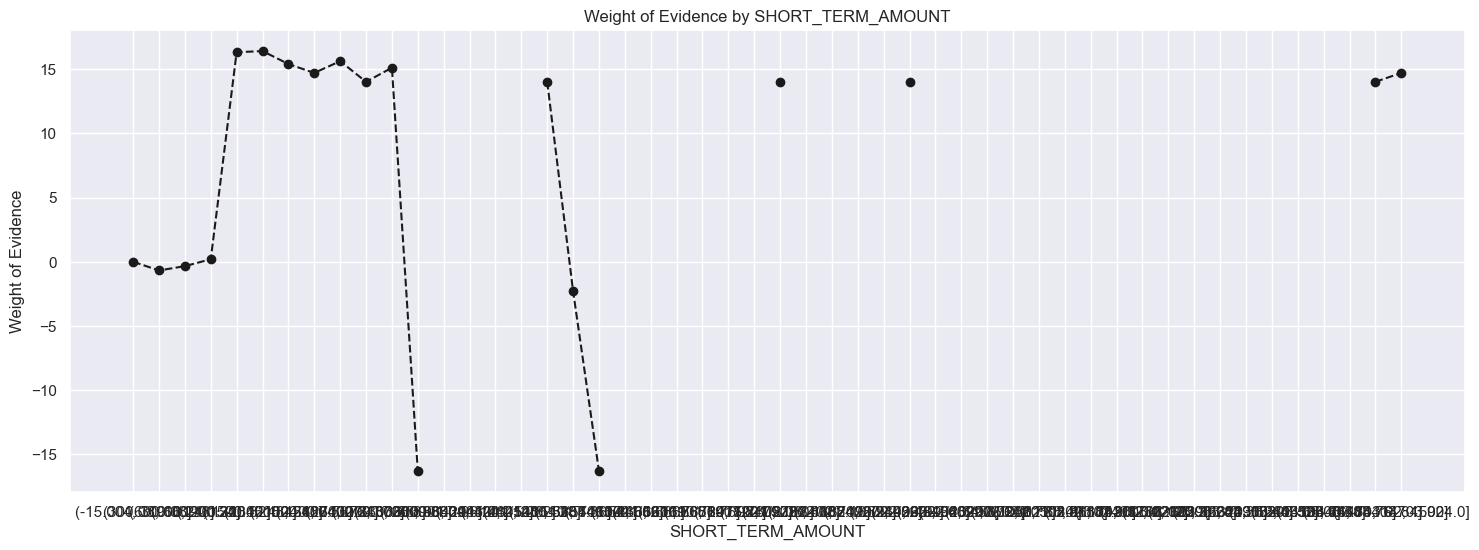

In [1992]:
plot_by_woe(df_temp)

In [1934]:
x = df_inputs_prepr['SHORT_TERM_AMOUNT']

df_inputs_prepr['SHORT_TERM_AMOUNT:<=300.08']     = np.where(x <= 300.08, 1, 0)
df_inputs_prepr['SHORT_TERM_AMOUNT:>300.08']      = np.where(x > 300.08, 1, 0)

In [1993]:
df_temp = woe_ordered_continuous ( df_iv,'INCOME_STRESS' , df_targets_prepr)
df_temp

,INCOME_STRESS,n_obs,prop_bad,prop_n_obs,n_bad,n_good,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-2.19e-07, 4.37e-06]",6260,0.092173,0.698739,577.0,5683.0,0.698672,0.699394,-0.001032,NaN,NaN,0.121051
1,"(4.37e-06, 8.74e-06]",1441,0.097155,0.160844,140.0,1301.0,0.159946,0.169697,-0.059179,0.004982,0.058146,0.121051
2,"(8.74e-06, 1.31e-05]",567,0.088183,0.063288,50.0,517.0,0.063560,0.060606,0.047595,0.008971,0.106774,0.121051
3,"(1.31e-05, 1.75e-05]",234,0.064103,0.026119,15.0,219.0,0.026924,0.018182,0.392597,0.024081,0.345002,0.121051
4,"(1.75e-05, 2.19e-05]",120,0.108333,0.013394,13.0,107.0,0.013155,0.015758,-0.180545,0.044231,0.573142,0.121051
5,"(2.19e-05, 2.62e-05]",74,0.067568,0.008260,5.0,69.0,0.008483,0.006061,0.336244,0.040766,0.516789,0.121051
6,"(2.62e-05, 3.06e-05]",67,0.074627,0.007479,5.0,62.0,0.007622,0.006061,0.229272,0.007059,0.106972,0.121051
7,"(3.06e-05, 3.5e-05]",29,0.034483,0.003237,1.0,28.0,0.003442,0.001212,1.043780,0.040144,0.814508,0.121051
8,"(3.5e-05, 3.93e-05]",20,0.000000,0.002232,0.0,20.0,0.002459,0.000000,17.017775,0.034483,15.973995,0.121051
9,"(3.93e-05, 4.37e-05]",35,0.085714,0.003907,3.0,32.0,0.003934,0.003636,0.078699,0.085714,16.939076,0.121051


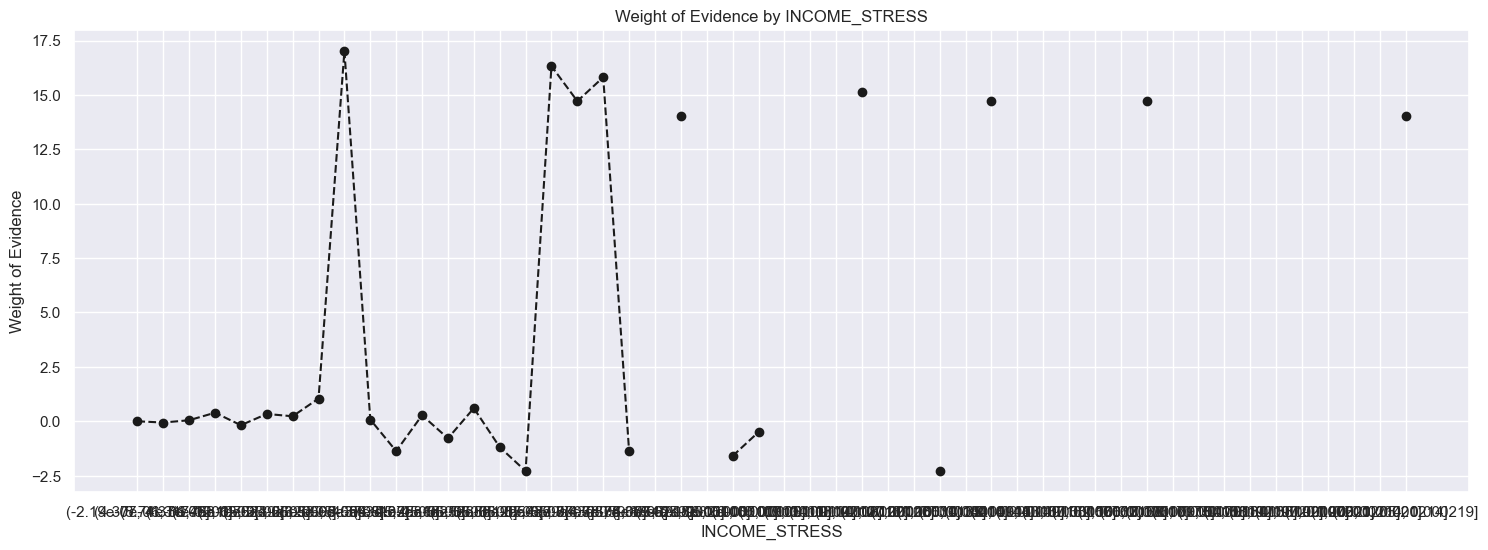

In [1994]:
plot_by_woe(df_temp)

In [1936]:
x = df_inputs_prepr['INCOME_STRESS']

df_inputs_prepr['INCOME_STRESS:<=4.37e-06']      = np.where(x <= 4.37e-06, 1, 0)
df_inputs_prepr['INCOME_STRESS:4.37e-06-1.31e-05'] = np.where((x > 4.37e-06) & (x <= 1.31e-05), 1, 0)
df_inputs_prepr['INCOME_STRESS:1.31e-05-3.06e-05'] = np.where((x > 1.31e-05) & (x <= 3.06e-05), 1, 0)
df_inputs_prepr['INCOME_STRESS:3.06e-05-8.74e-05'] = np.where((x > 3.06e-05) & (x <= 8.74e-05), 1, 0)
df_inputs_prepr['INCOME_STRESS:>8.74e-05']        = np.where(x > 8.74e-05, 1, 0)

In [1995]:
df_temp = woe_ordered_continuous ( df_iv,'MID_TERM_AMOUNT' , df_targets_prepr)
df_temp

,MID_TERM_AMOUNT,n_obs,prop_bad,prop_n_obs,n_bad,n_good,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-1.825, 36.5]",6846,0.087935,0.764148,602.0,6244.0,0.767642,0.729697,0.050694,NaN,NaN,0.150357
1,"(36.5, 73.0]",1115,0.107623,0.124456,120.0,995.0,0.122326,0.145455,-0.173174,0.019689,0.223868,0.150357
2,"(73.0, 109.5]",496,0.120968,0.055363,60.0,436.0,0.053602,0.072727,-0.305127,0.013344,0.131953,0.150357
3,"(109.5, 146.0]",208,0.096154,0.023217,20.0,188.0,0.023113,0.024242,-0.047715,0.024814,0.257412,0.150357
4,"(146.0, 182.5]",108,0.092593,0.012055,10.0,98.0,0.012048,0.012121,-0.006042,0.003561,0.041673,0.150357
5,"(182.5, 219.0]",53,0.018868,0.005916,1.0,52.0,0.006393,0.001212,1.662819,0.073725,1.668861,0.150357
6,"(219.0, 255.5]",29,0.172414,0.003237,5.0,24.0,0.002951,0.006061,-0.719809,0.153546,2.382628,0.150357
7,"(255.5, 292.0]",25,0.000000,0.002790,0.0,25.0,0.003074,0.000000,17.240919,0.172414,17.960727,0.150357
8,"(292.0, 328.5]",22,0.090909,0.002456,2.0,20.0,0.002459,0.002424,0.014160,0.090909,17.226758,0.150357
9,"(328.5, 365.0]",14,0.071429,0.001563,1.0,13.0,0.001598,0.001212,0.276525,0.019481,0.262364,0.150357


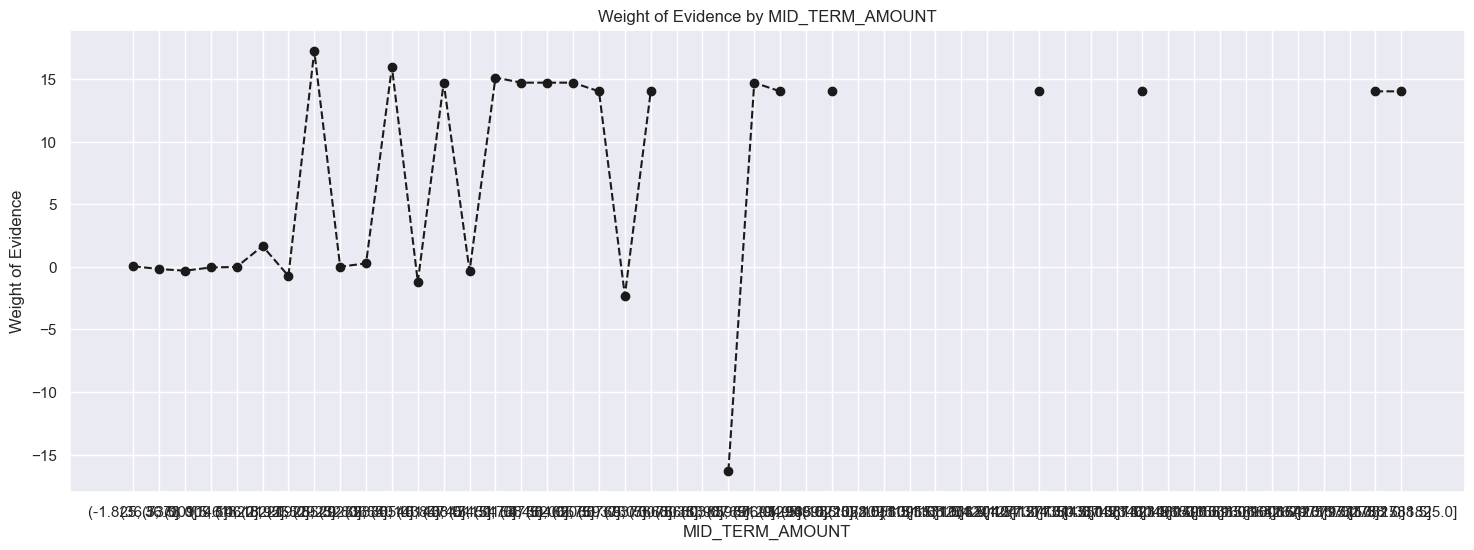

In [1996]:
plot_by_woe(df_temp)

In [1938]:
x = df_inputs_prepr['MID_TERM_AMOUNT']

df_inputs_prepr['MID_TERM_AMOUNT:<=36.5']       = np.where(x <= 36.5, 1, 0)
df_inputs_prepr['MID_TERM_AMOUNT:36.5-109.5']   = np.where((x > 36.5) & (x <= 109.5), 1, 0)
df_inputs_prepr['MID_TERM_AMOUNT:109.5-219.0']  = np.where((x > 109.5) & (x <= 219.0), 1, 0)
df_inputs_prepr['MID_TERM_AMOUNT:219.0-365.0']  = np.where((x > 219.0) & (x <= 365.0), 1, 0)
df_inputs_prepr['MID_TERM_AMOUNT:>365.0']       = np.where(x > 365.0, 1, 0)

In [1997]:
df_temp = woe_ordered_continuous ( df_iv,'BAL_CHANGE_ALL' , df_targets_prepr)
df_temp #WOE not monotonic

,BAL_CHANGE_ALL,n_obs,prop_bad,prop_n_obs,n_bad,n_good,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-1082.014, -1040.975]",31,0.064516,0.003460,2.0,29.0,0.003565,0.002424,0.385724,NaN,NaN,0.440499
1,"(-1040.975, -1001.89]",5,0.200000,0.000558,1.0,4.0,0.000492,0.001212,-0.902130,0.135484,1.287854,0.440499
2,"(-1001.89, -962.806]",2,0.000000,0.000223,0.0,2.0,0.000246,0.000000,14.715190,0.200000,15.617321,0.440499
3,"(-962.806, -923.721]",2,0.000000,0.000223,0.0,2.0,0.000246,0.000000,14.715190,0.000000,0.000000,0.440499
4,"(-923.721, -884.636]",3,0.000000,0.000335,0.0,3.0,0.000369,0.000000,15.120655,0.000000,0.405465,0.440499
5,"(-884.636, -845.551]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.440499
6,"(-845.551, -806.466]",1,0.000000,0.000112,0.0,1.0,0.000123,0.000000,14.022044,NaN,NaN,0.440499
7,"(-806.466, -767.382]",2,0.000000,0.000223,0.0,2.0,0.000246,0.000000,14.715190,0.000000,0.693147,0.440499
8,"(-767.382, -728.297]",2,0.000000,0.000223,0.0,2.0,0.000246,0.000000,14.715190,0.000000,0.000000,0.440499
9,"(-728.297, -689.212]",1,0.000000,0.000112,0.0,1.0,0.000123,0.000000,14.022044,0.000000,0.693147,0.440499


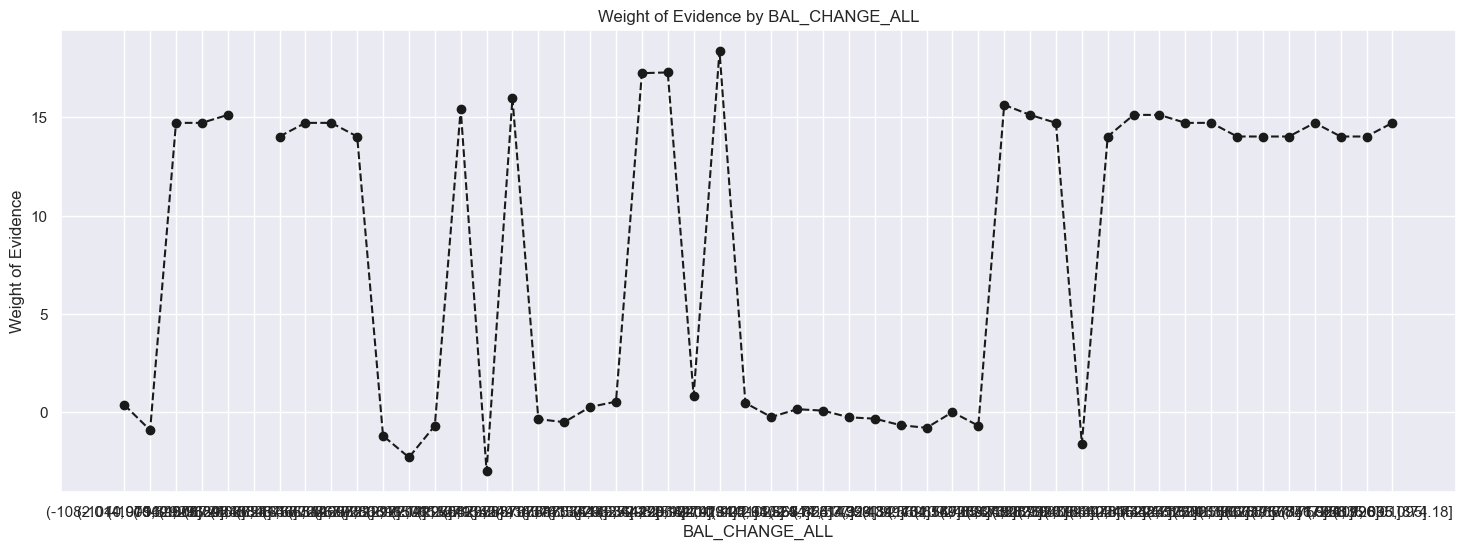

In [1998]:
plot_by_woe(df_temp)

In [1940]:
x = df_inputs_prepr['BAL_CHANGE_ALL']

df_inputs_prepr['BAL_CHANGE_ALL:<= -181.11']     = np.where(x <= -181.11, 1, 0)
df_inputs_prepr['BAL_CHANGE_ALL:-181.11 to 14.314'] = np.where((x > -181.11) & (x <= 14.314), 1, 0)
df_inputs_prepr['BAL_CHANGE_ALL:14.314 to 92.484']  = np.where((x > 14.314) & (x <= 92.484), 1, 0)
df_inputs_prepr['BAL_CHANGE_ALL:92.484 to 326.993'] = np.where((x > 92.484) & (x <= 326.993), 1, 0)
df_inputs_prepr['BAL_CHANGE_ALL:>326.993']         = np.where(x > 326.993, 1, 0)

In [1941]:
df_inputs_prepr.head()

,Age,gender,occupation,month_incom,operating_system,phone_provider,SHORT_TERM_AMOUNT,MID_TERM_AMOUNT,LONG_TERM_AMOUNT,SHORT_TERM_COUNT_BANK,MID_TERM_COUNT_BANK,LONG_TERM_COUNT_BANK,SHORT_TERM_COUNT_NON_BANK,MID_TERM_COUNT_NON_BANK,LONG_TERM_COUNT_NON_BANK,NUM_LOANS_BANK,NUM_LOANS_NON_BANK,NUM_CC_BANK,NUM_CC_NON_BANK,NUM_RELATIONSHIP,OUTS_BAL_LOAN_M1,OUTS_BAL_CC_M1,OUTS_BAL_ALL_M1,OUTS_BAL_LOAN_M3,OUTS_BAL_CC_M3,OUTS_BAL_ALL_M3,OUTS_BAL_LOAN_M6,OUTS_BAL_CC_M6,OUTS_BAL_ALL_M6,OUTS_BAL_LOAN_M12,OUTS_BAL_CC_M12,OUTS_BAL_ALL_M12,CC_LIMIT_TOTAL,OUTS_BAL_CC_CURRENT,ENQ_3M,ENQ_12M,NUM_NEW_LOAN_3M,NUM_NEW_LOAN_12M,address,mths_since_issue_d,BAL_CHANGE_ALL,AVG_OUTS_BAL_ALL,INCOME_STRESS,occupation:Business_Households,occupation:CASUAL_STAFF,occupation:EMPLOYEE,occupation:ENGINEER,occupation:FARMER,occupation:FREELANCER,occupation:HOUSE_WIFE,occupation:LAYWER_POLICE_ARMY_JOURNALIST,occupation:MEDICAL_ENGINEER,occupation:MEDICAL_WORKER,occupation:OTHER,occupation:STUDENT,occupation:WORKER,address:AG,address:BD,address:BG,address:BK,address:BL,address:BN,address:BP,address:BRVT,address:BT,address:BĐ,address:CB,address:CM,address:CT,address:DL,address:DN,address:DNN,address:DT,address:DkN,address:GL,address:HB,address:HCM,address:HD,address:HG,address:HN,address:HP,address:HT,address:HY,address:KG,address:KH,address:LA,address:LC,address:LD,address:LS,address:LĐ,address:NA,address:NB,address:ND,address:NT,address:NĐ,address:PT,address:PY,address:QB,address:QN,address:QT,address:SL,address:ST,address:TB,address:TG,address:TH,address:TN,address:TQ,address:TTH,address:TV,address:VL,address:VP,address:ĐB,address:ĐL,address:ĐT,occupation:FARMER_Business_Households_CASUAL_STAFF,occupation:EMPLOYEE_ENGINEER,occupation:FREELANCER_STUDENT,occupation:LPAJ_HOUSE_WIFE_ME_MW_R,address:ĐB_GL_LD_VL_NT,address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA,address:QN_BG_LĐ_DT_KH_AG_TTH_BT_PY_TB,address:HD_HG_PT_BN_DNN_DN,address:HB_HY_NA_VP_TH_CT_BD_BRVT_QT_ĐT_LC_NĐ_CB,address:KG_ND_TN_LS,address:Rare,NUM_CC_BANK:0,NUM_CC_BANK:1,NUM_CC_BANK:2,NUM_CC_BANK:3-4,NUM_CC_BANK:5-8,NUM_CC_BANK:9-18,ENQ_3M:1,ENQ_3M:2,ENQ_3M:3,ENQ_3M:4-5,ENQ_3M:6-19,ENQ_12M:<=2.38,ENQ_12M:2.38-3.76,ENQ_12M:3.76-5.14,ENQ_12M:5.14-7.9,ENQ_12M:7.9-12.04,ENQ_12M:12.04-18.94,ENQ_12M:>18.94,OUTS_BAL_CC_M12:<=4.04,OUTS_BAL_CC_M12:4.04-20.2,OUTS_BAL_CC_M12:20.2-36.36,OUTS_BAL_CC_M12:36.36-52.52,OUTS_BAL_CC_M12:52.52-80.8,OUTS_BAL_CC_M12:>80.8,OUTS_BAL_LOAN_M12:<=17.32,OUTS_BAL_LOAN_M12:17.32-51.96,OUTS_BAL_LOAN_M12:51.96-103.92,OUTS_BAL_LOAN_M12:103.92-173.2,OUTS_BAL_LOAN_M12:173.2-277.12,OUTS_BAL_LOAN_M12:>277.12,OUTS_BAL_CC_M1:<=4.42,OUTS_BAL_CC_M1:4.42-17.68,OUTS_BAL_CC_M1:17.68-35.36,OUTS_BAL_CC_M1:35.36-70.72,OUTS_BAL_CC_M1:70.72-150.28,OUTS_BAL_CC_M1:>150.28,SHORT_TERM_AMOUNT:<=300.08,SHORT_TERM_AMOUNT:>300.08,INCOME_STRESS:<=4.37e-06,INCOME_STRESS:4.37e-06-1.31e-05,INCOME_STRESS:1.31e-05-3.06e-05,INCOME_STRESS:3.06e-05-8.74e-05,INCOME_STRESS:>8.74e-05,MID_TERM_AMOUNT:<=36.5,MID_TERM_AMOUNT:36.5-109.5,MID_TERM_AMOUNT:109.5-219.0,MID_TERM_AMOUNT:219.0-365.0,MID_TERM_AMOUNT:>365.0,BAL_CHANGE_ALL:<= -181.11,BAL_CHANGE_ALL:-181.11 to 14.314,BAL_CHANGE_ALL:14.314 to 92.484,BAL_CHANGE_ALL:92.484 to 326.993,BAL_CHANGE_ALL:>326.993
7103,33.0,FEMALE,OTHER,17000000.0,IOS,viettel,36,391,0,1,2,0,1,2,0,3,3,2,1,9,425.0,38,463.0,444.0,40.0,484.0,418.0,30.0,448.0,427,0,427.0,40.0,38.0,2,18,1,3,PT,23.0,15.0,455.50,2.723529e-05,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0
7388,28.0,MALE,WORKER,8000000.0,IOS,viettel,26,0,0,1,0,0,0,0,0,1,0,1,1,3,0.0,0,0.0,28.0,57.0,85.0,20.0,0.0,20.0,0,0,0.0,77.0,57.0,4,8,1,2,TB,23.0,-20.0,26.25,0.000000e+00,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,

In [1942]:
df_inputs_prepr.columns.values

array(['Age', 'gender', 'occupation', 'month_incom', 'operating_system',
       'phone_provider', 'SHORT_TERM_AMOUNT', 'MID_TERM_AMOUNT',
       'LONG_TERM_AMOUNT', 'SHORT_TERM_COUNT_BANK', 'MID_TERM_COUNT_BANK',
       'LONG_TERM_COUNT_BANK', 'SHORT_TERM_COUNT_NON_BANK',
       'MID_TERM_COUNT_NON_BANK', 'LONG_TERM_COUNT_NON_BANK',
       'NUM_LOANS_BANK', 'NUM_LOANS_NON_BANK', 'NUM_CC_BANK',
       'NUM_CC_NON_BANK', 'NUM_RELATIONSHIP', 'OUTS_BAL_LOAN_M1',
       'OUTS_BAL_CC_M1', 'OUTS_BAL_ALL_M1', 'OUTS_BAL_LOAN_M3',
       'OUTS_BAL_CC_M3', 'OUTS_BAL_ALL_M3', 'OUTS_BAL_LOAN_M6',
       'OUTS_BAL_CC_M6', 'OUTS_BAL_ALL_M6', 'OUTS_BAL_LOAN_M12',
       'OUTS_BAL_CC_M12', 'OUTS_BAL_ALL_M12', 'CC_LIMIT_TOTAL',
       'OUTS_BAL_CC_CURRENT', 'ENQ_3M', 'ENQ_12M', 'NUM_NEW_LOAN_3M',
       'NUM_NEW_LOAN_12M', 'address', 'mths_since_issue_d',
       'BAL_CHANGE_ALL', 'AVG_OUTS_BAL_ALL', 'INCOME_STRESS',
       'occupation:Business_Households', 'occupation:CASUAL_STAFF',
       'occupation:E

In [1943]:
#export to csv
inputs_train = df_inputs_prepr
inputs_train.to_csv('loan_data_inputs_train.csv')
targets_train.to_csv('loan_data_targets_train.csv')

In [21]:
df_inputs_prepr.head()

,Age,gender,occupation,month_incom,operating_system,phone_provider,SHORT_TERM_AMOUNT,MID_TERM_AMOUNT,LONG_TERM_AMOUNT,SHORT_TERM_COUNT_BANK,MID_TERM_COUNT_BANK,LONG_TERM_COUNT_BANK,SHORT_TERM_COUNT_NON_BANK,MID_TERM_COUNT_NON_BANK,LONG_TERM_COUNT_NON_BANK,NUM_LOANS_BANK,NUM_LOANS_NON_BANK,NUM_CC_BANK,NUM_CC_NON_BANK,NUM_RELATIONSHIP,OUTS_BAL_LOAN_M1,OUTS_BAL_CC_M1,OUTS_BAL_ALL_M1,OUTS_BAL_LOAN_M3,OUTS_BAL_CC_M3,OUTS_BAL_ALL_M3,OUTS_BAL_LOAN_M6,OUTS_BAL_CC_M6,OUTS_BAL_ALL_M6,OUTS_BAL_LOAN_M12,OUTS_BAL_CC_M12,OUTS_BAL_ALL_M12,CC_LIMIT_TOTAL,OUTS_BAL_CC_CURRENT,ENQ_3M,ENQ_12M,NUM_NEW_LOAN_3M,NUM_NEW_LOAN_12M,address,mths_since_issue_d,BAL_CHANGE_ALL,AVG_OUTS_BAL_ALL,INCOME_STRESS
7103,33.0,FEMALE,OTHER,17000000.0,IOS,viettel,36,391,0,1,2,0,1,2,0,3,3,2,1,9,425.0,38,463.0,444.0,40.0,484.0,418.0,30.0,448.0,427,0,427.0,40.0,38.0,2,18,1,3,PT,23.0,15.0,455.50,2.723529e-05
7388,28.0,MALE,WORKER,8000000.0,IOS,viettel,26,0,0,1,0,0,0,0,0,1,0,1,1,3,0.0,0,0.0,28.0,57.0,85.0,20.0,0.0,20.0,0,0,0.0,77.0,57.0,4,8,1,2,TB,23.0,-20.0,26.25,0.000000e+00
6044,30.0,MALE,OTHER,13000000.0,ANDROID,viettel,16,0,0,0,0,0,2,0,0,0,2,0,1,3,19.0,10,29.0,22.0,10.0,32.0,0.0,0.0,0.0,0,0,0.0,10.0,10.0,3,4,0,2,HN,23.0,29.0,15.25,2.230769e-06
418,19.0,MALE,WORKER,5000000.0,IOS,mobifone,3,0,0,1,0,0,1,0,0,1,1,0,0,2,2.0,0,2.0,1.0,0.0,1.0,1.0,0.0,1.0,5,0,5.0,0.0,0.0,1,1,1,1,DN,25.0,1.0,2.25,4.000000e-07
4921,20.0,FEMALE,WORKER,9000000.0,0,viettel,19,0,0,2,0,0,1,0,0,2,1,1,0,4,19.0,1,20.0,9.0,1.0,10.0,1.0,2.0,3.0,0,0,0.0,10.0,1.0,1,1,2,3,HN,23.0,17.0,8.25,2.222222e-06


In [147]:
# inputs_train, inputs_test, targets_train, targets_test = train_test_split(
#     loan_data2_fe, y, test_size=0.2, stratify=y,random_state= 42) 

# df_inputs_prepr = inputs_train
# df_targets_prepr = targets_train

to_drop = ['OUTS_BAL_ALL_M12','OUTS_BAL_ALL_M1','OUTS_BAL_ALL_M6', 'OUTS_BAL_LOAN_M6','OUTS_BAL_LOAN_M3']
X_train = inputs_train.drop(to_drop, axis=1)
# y_train = targets_train.drop(to_drop, axis=1)

# train
model = LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    importance_type='gain',
    class_weight='balanced',
    verbosity=-1, random_state=42, predict_disable_shape_check= True
)

model.fit(X_train , y_train)

# feature importance
imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

# sort
imp = imp.sort_values('importance', ascending=False)
imp

,feature,importance
4,operating_system,33532.217811
33,address,9672.784622
3,month_incom,2256.990786
25,OUTS_BAL_LOAN_M12,2141.437086
35,BAL_CHANGE_ALL,2073.525230
0,Age,1596.477339
17,NUM_CC_BANK,1414.385338
29,ENQ_3M,1242.167278
23,OUTS_BAL_ALL_M3,1159.388799
37,INCOME_STRESS,1113.053773


C:\Users\Admin\anaconda3\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


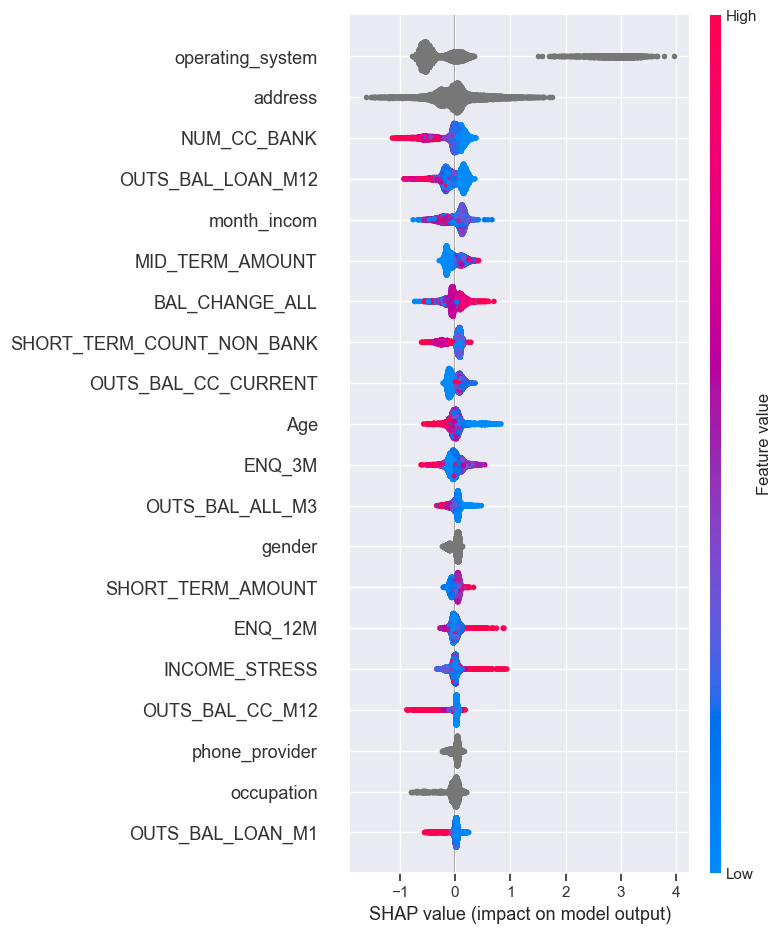

In [149]:
# SHAP explainer
explainer = shap.TreeExplainer(model)

# SHAP values
shap_values = explainer.shap_values(X_train)

# summary plot
shap.summary_plot( shap_values, X_train)

In [150]:
shap_imp = pd.DataFrame({'feature':X_train.columns,'importance': np.abs(shap_values).mean(axis=0)})
shap_imp = shap_imp.sort_values('importance',ascending=False)
shap_imp

,feature,importance
4,operating_system,0.651574
33,address,0.260722
17,NUM_CC_BANK,0.158111
25,OUTS_BAL_LOAN_M12,0.153343
3,month_incom,0.148699
7,MID_TERM_AMOUNT,0.116610
35,BAL_CHANGE_ALL,0.114666
12,SHORT_TERM_COUNT_NON_BANK,0.113411
28,OUTS_BAL_CC_CURRENT,0.096830
0,Age,0.095331


In [ ]:
'''KEEP
4   operating_system
33  address
25  OUTS_BAL_LOAN_M12
3   month_incom
35  BAL_CHANGE_ALL
17  NUM_CC_BANK
7   MID_TERM_AMOUNT
29  ENQ_3M
12  SHORT_TERM_COUNT_NON_BANK
28  OUTS_BAL_CC_CURRENT
0   Age
23  OUTS_BAL_ALL_M3
30  ENQ_12M
37  INCOME_STRESS
26  OUTS_BAL_CC_M12
6   SHORT_TERM_AMOUNT

POSSIBLE KEEP
36  AVG_OUTS_BAL_ALL
20  OUTS_BAL_LOAN_M1
34  mths_since_issue_d
27  CC_LIMIT_TOTAL
2   occupation
24  OUTS_BAL_CC_M6
31  NUM_NEW_LOAN_3M
32  NUM_NEW_LOAN_12M
16  NUM_LOANS_NON_BANK'''

In [41]:
imp['feature'].values

array(['operating_system', 'address', 'month_incom', 'Age',
       'BAL_CHANGE_ALL', 'OUTS_BAL_LOAN_M12', 'OUTS_BAL_LOAN_M3',
       'NUM_CC_BANK', 'OUTS_BAL_ALL_M12', 'MID_TERM_AMOUNT', 'ENQ_12M',
       'INCOME_STRESS', 'ENQ_3M', 'SHORT_TERM_AMOUNT', 'OUTS_BAL_ALL_M3',
       'OUTS_BAL_ALL_M6', 'SHORT_TERM_COUNT_NON_BANK',
       'OUTS_BAL_CC_CURRENT', 'OUTS_BAL_CC_M12', 'occupation',
       'AVG_OUTS_BAL_ALL', 'OUTS_BAL_LOAN_M6', 'CC_LIMIT_TOTAL',
       'mths_since_issue_d', 'NUM_LOANS_NON_BANK', 'OUTS_BAL_LOAN_M1',
       'NUM_NEW_LOAN_12M', 'OUTS_BAL_CC_M1', 'OUTS_BAL_CC_M6',
       'NUM_RELATIONSHIP', 'OUTS_BAL_ALL_M1', 'phone_provider',
       'NUM_CC_NON_BANK', 'NUM_NEW_LOAN_3M', 'gender',
       'MID_TERM_COUNT_NON_BANK', 'OUTS_BAL_CC_M3',
       'SHORT_TERM_COUNT_BANK', 'LONG_TERM_AMOUNT', 'NUM_LOANS_BANK',
       'MID_TERM_COUNT_BANK', 'LONG_TERM_COUNT_BANK',
       'LONG_TERM_COUNT_NON_BANK'], dtype=object)

In [58]:
imp['feature'].values #new

array(['operating_system', 'address', 'month_incom', 'OUTS_BAL_LOAN_M12',
       'BAL_CHANGE_ALL', 'Age', 'NUM_CC_BANK', 'ENQ_3M',
       'OUTS_BAL_ALL_M3', 'INCOME_STRESS', 'ENQ_12M', 'MID_TERM_AMOUNT',
       'AVG_OUTS_BAL_ALL', 'SHORT_TERM_COUNT_NON_BANK',
       'OUTS_BAL_LOAN_M1', 'OUTS_BAL_CC_CURRENT', 'CC_LIMIT_TOTAL',
       'OUTS_BAL_CC_M12', 'SHORT_TERM_AMOUNT', 'mths_since_issue_d',
       'OUTS_BAL_CC_M1', 'occupation', 'OUTS_BAL_CC_M6',
       'NUM_NEW_LOAN_3M', 'NUM_NEW_LOAN_12M', 'phone_provider',
       'NUM_RELATIONSHIP', 'NUM_LOANS_NON_BANK',
       'MID_TERM_COUNT_NON_BANK', 'OUTS_BAL_CC_M3', 'NUM_CC_NON_BANK',
       'gender', 'SHORT_TERM_COUNT_BANK', 'NUM_LOANS_BANK',
       'LONG_TERM_AMOUNT', 'MID_TERM_COUNT_BANK', 'LONG_TERM_COUNT_BANK',
       'LONG_TERM_COUNT_NON_BANK'], dtype=object)

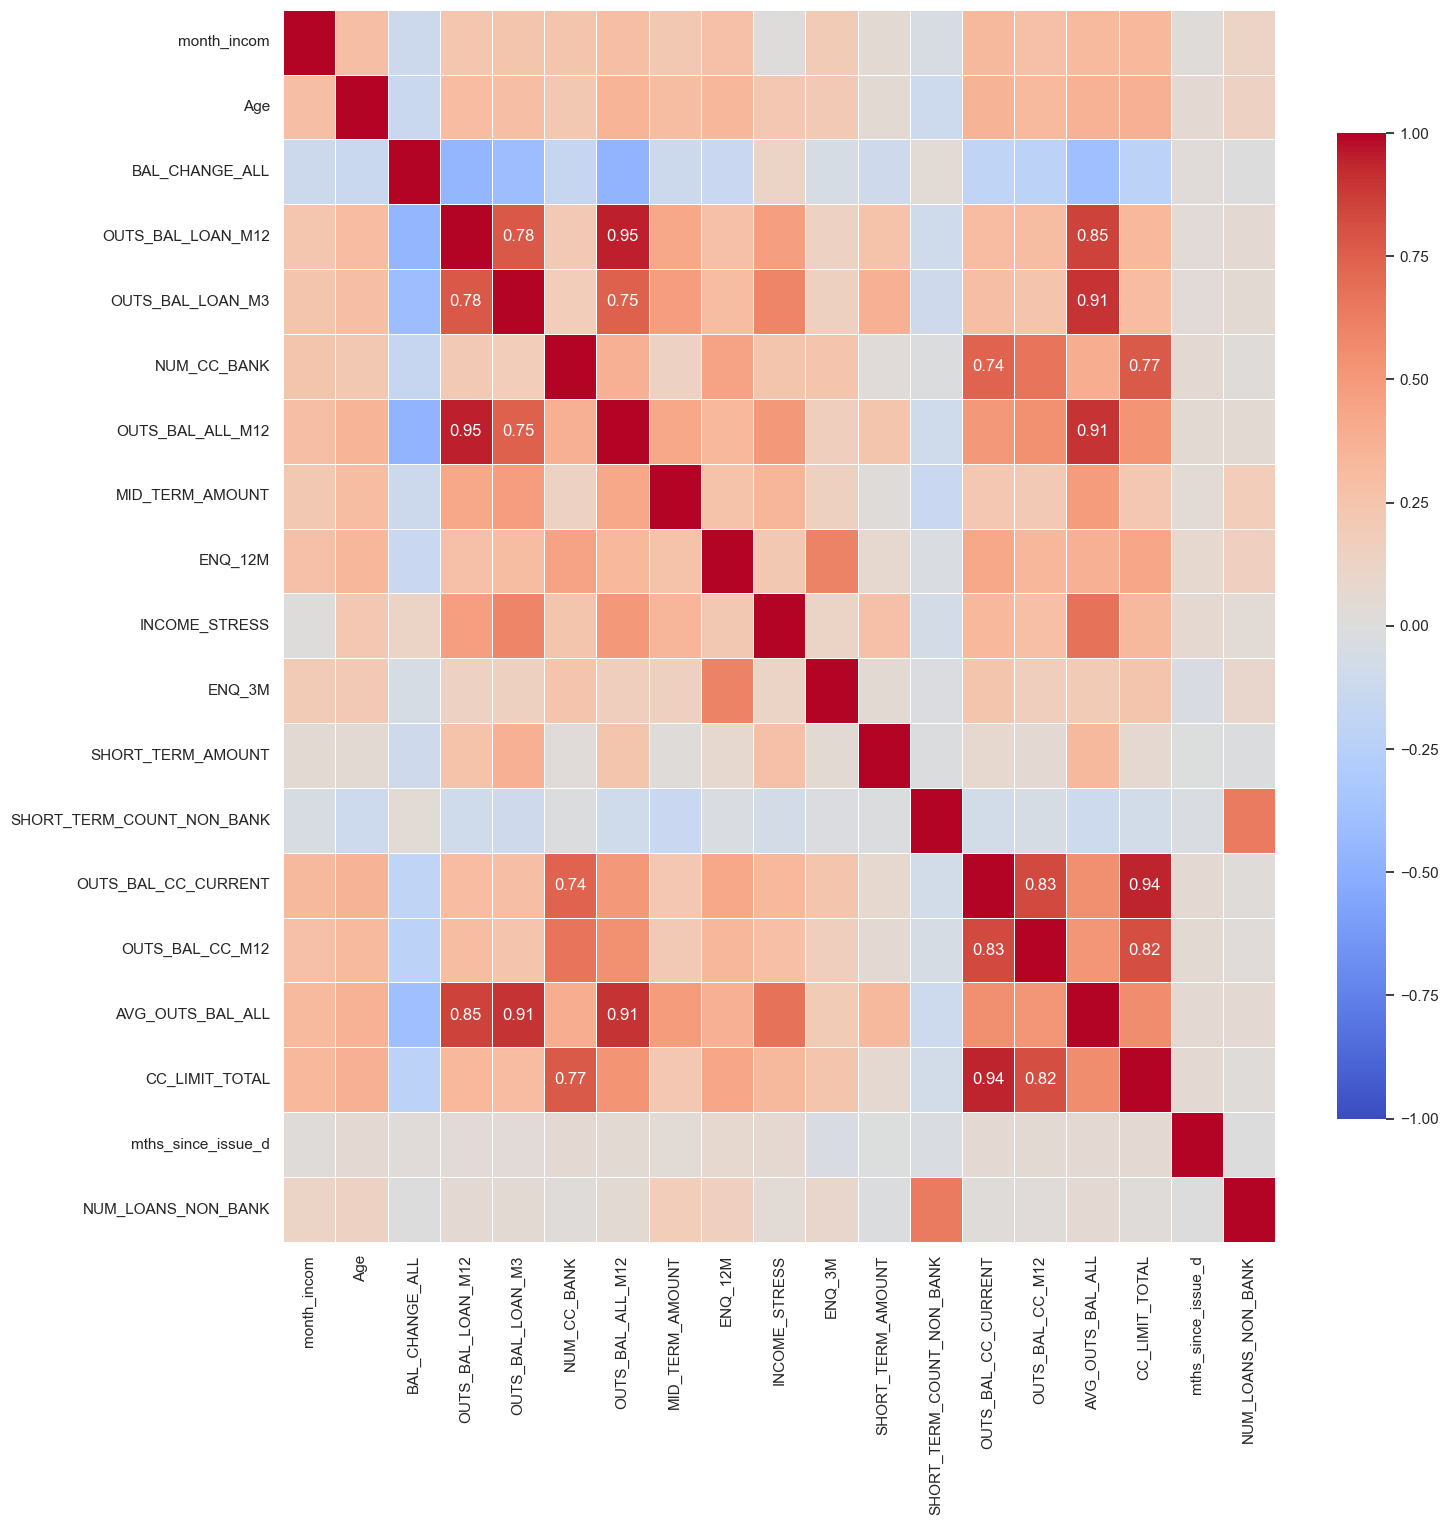

In [49]:
corr = loan_data2_fe[original_features].corr(numeric_only=True) #check corr of whold dataset so we use loan_data2_fe

# Create a version of the correlation matrix where values < 0.7 are empty strings
annot_mask = corr.applymap(lambda x: f'{x:.2f}' if 0.7 <= abs(x) < 1 else "")

plt.figure(figsize=(16, 16))

sns.heatmap(
    corr, 
    annot=annot_mask,   # Use our filtered strings for annotations
    fmt="",             # Format must be empty because we pre-formatted the strings
    cmap='coolwarm', 
    linewidths=0.5,
    vmin=-1, vmax=1,    # Ensure the scale is always -1 to 1
    cbar_kws={"shrink": .8}
)
plt.show()

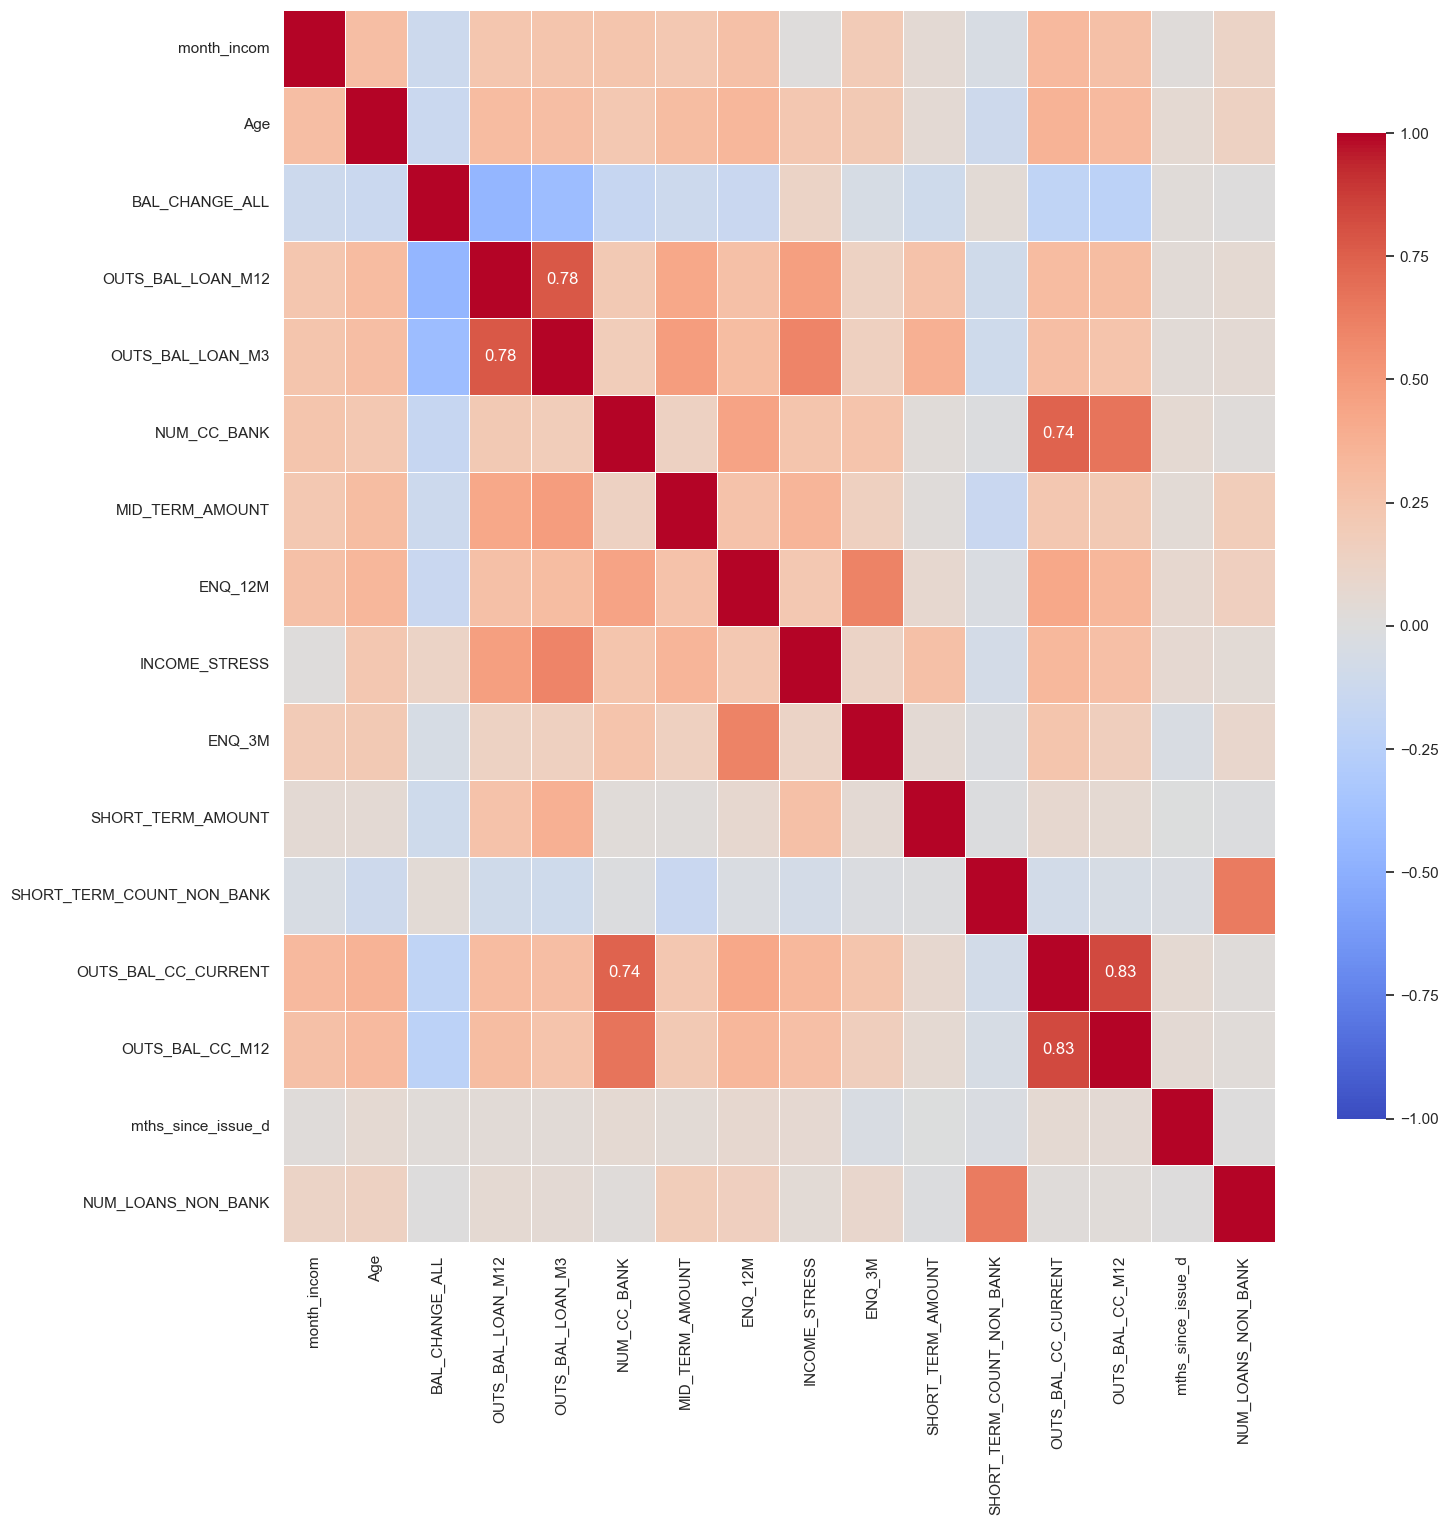

In [61]:
original_features = ['operating_system', 'address', 'month_incom', 'Age',
       'BAL_CHANGE_ALL', 'OUTS_BAL_LOAN_M12', 'OUTS_BAL_LOAN_M3',
       'NUM_CC_BANK', #'OUTS_BAL_ALL_M12',
                     'MID_TERM_AMOUNT', 'ENQ_12M',
       'INCOME_STRESS', 'ENQ_3M', 'SHORT_TERM_AMOUNT',
#                      'OUTS_BAL_ALL_M3',       'OUTS_BAL_ALL_M6', 
                     'SHORT_TERM_COUNT_NON_BANK',
       'OUTS_BAL_CC_CURRENT', 'OUTS_BAL_CC_M12', 'occupation',
       #'AVG_OUTS_BAL_ALL',# 'OUTS_BAL_LOAN_M6', 
#                      'CC_LIMIT_TOTAL',
       'mths_since_issue_d', 'NUM_LOANS_NON_BANK', 
#                      'OUTS_BAL_LOAN_M1'
                    ]
corr = loan_data2_fe[original_features].corr(numeric_only=True) #check corr of whold dataset so we use loan_data2_fe

# Create a version of the correlation matrix where values < 0.7 are empty strings
annot_mask = corr.applymap(lambda x: f'{x:.2f}' if 0.7 <= abs(x) < 1 else "")

plt.figure(figsize=(16, 16))

sns.heatmap(
    corr, 
    annot=annot_mask,   # Use our filtered strings for annotations
    fmt="",             # Format must be empty because we pre-formatted the strings
    cmap='coolwarm', 
    linewidths=0.5,
    vmin=-1, vmax=1,    # Ensure the scale is always -1 to 1
    cbar_kws={"shrink": .8}
)
plt.show()

In [ ]:
'''FROM LIGHTGBM n SHAP:
KEEP
4   operating_system
33  address
25  OUTS_BAL_LOAN_M12
3   month_incom
35  BAL_CHANGE_ALL
17  NUM_CC_BANK
7   MID_TERM_AMOUNT
29  ENQ_3M
12  SHORT_TERM_COUNT_NON_BANK
28  OUTS_BAL_CC_CURRENT
0   Age
23  OUTS_BAL_ALL_M3
30  ENQ_12M
37  INCOME_STRESS
26  OUTS_BAL_CC_M12
6   SHORT_TERM_AMOUNT

POSSIBLE KEEP
36  AVG_OUTS_BAL_ALL
20  OUTS_BAL_LOAN_M1
34  mths_since_issue_d
27  CC_LIMIT_TOTAL
2   occupation
24  OUTS_BAL_CC_M6
31  NUM_NEW_LOAN_3M
32  NUM_NEW_LOAN_12M
16  NUM_LOANS_NON_BANK'''

In [76]:
original_features = ['operating_system', 'address', 'month_incom', 'OUTS_BAL_LOAN_M12',
       'BAL_CHANGE_ALL', 'OUTS_BAL_LOAN_M3', 'Age', 'ENQ_12M',
       'NUM_CC_BANK', 'MID_TERM_AMOUNT', 'INCOME_STRESS', 'ENQ_3M',
       'OUTS_BAL_ALL_M3', 'SHORT_TERM_AMOUNT', 'AVG_OUTS_BAL_ALL',
       'OUTS_BAL_CC_CURRENT', 'SHORT_TERM_COUNT_NON_BANK',
       'OUTS_BAL_CC_M12', 'occupation', 'OUTS_BAL_LOAN_M1',
       'CC_LIMIT_TOTAL', 'OUTS_BAL_CC_M1', 'OUTS_BAL_CC_M6',
       'mths_since_issue_d', 'NUM_LOANS_NON_BANK', 'NUM_NEW_LOAN_12M']

In [ ]:
# pip install catboost

#the code below is the split (already run above)
# inputs_train, inputs_test, targets_train, targets_test = train_test_split(
#     loan_data2_fe, y, test_size=0.2, stratify=y,random_state= 42) 

# df_inputs_prepr = inputs_train
# df_targets_prepr = targets_train

In [113]:
# FEATURES
original_features = ['operating_system', 'address','month_incom','Age','BAL_CHANGE_ALL','OUTS_BAL_LOAN_M12',
    'OUTS_BAL_LOAN_M3',    'NUM_CC_BANK',    'MID_TERM_AMOUNT',    'ENQ_12M',    'INCOME_STRESS',    'ENQ_3M',
    'SHORT_TERM_AMOUNT',    'SHORT_TERM_COUNT_NON_BANK',    'OUTS_BAL_CC_CURRENT',
    'OUTS_BAL_CC_M12','occupation','mths_since_issue_d','NUM_LOANS_NON_BANK'
]
cat_cols = ['address','occupation','operating_system']

# split data into train and test datasets, ratio 8/2 
inputs_train, inputs_test, targets_train, targets_test = train_test_split(
    loan_data2_fe, y, test_size=0.2, stratify=y,random_state= 42) 

# TRAIN / TEST
X_train = inputs_train[original_features].copy()
X_test = inputs_test[original_features].copy()
y_train = targets_train.values.ravel()
y_test = targets_test.values.ravel()

# LABEL ENCODING
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform( X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# IMBALANCE
bad_rate = y_train.mean()
scale_pos_weight = (1 - bad_rate) / bad_rate

# CV + SCORING
cv = StratifiedKFold( n_splits=5,shuffle=True,random_state=42)
f2_scorer = make_scorer(fbeta_score,beta=2)

# MODELS + PARAMS
param_grids = {
    'LogReg': (LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
        { 'C': [0.01, 0.1, 1, 10]}),

    'RandomForest': ( RandomForestClassifier(class_weight='balanced',random_state=42),
        {'n_estimators': [200, 500],'max_depth': [4, 6, None],'min_samples_leaf': [10, 30] }),
    
    'AdaBoost': ( AdaBoostClassifier( random_state=42 ),
    { 'n_estimators': [100, 300], 'learning_rate': [0.03, 0.05, 0.1]}),
    
    'GradBoost': ( GradientBoostingClassifier( random_state=42),
    {'learning_rate': [0.03, 0.05],'n_estimators': [200, 500],'max_depth': [3],'subsample': [0.8] }),
    
    'ExtraTrees': (ExtraTreesClassifier( class_weight='balanced', random_state=42 ),
    {'n_estimators': [200, 500],'max_depth': [4, 6, None],'min_samples_leaf': [10, 30] }),
    
    'XGBoost': (XGBClassifier(eval_metric='aucpr',scale_pos_weight=scale_pos_weight,random_state=42),
        {'learning_rate': [0.03, 0.05],'n_estimators': [200, 500],'max_depth': [3, 5],'subsample': [0.8],
         'colsample_bytree': [0.8]}),

    'LightGBM': ( LGBMClassifier(objective='binary',is_unbalance=True,random_state=42,verbose=-1),
        { 'learning_rate': [0.03, 0.05], 'n_estimators': [200, 500], 'max_depth': [3, 5], 'num_leaves': [15, 31] }),

    'CatBoost': ( CatBoostClassifier( auto_class_weights='Balanced', verbose=0, random_state=42, allow_writing_files=False),
    {'learning_rate': [0.03, 0.05],'iterations': [200, 500],'depth': [4, 6]})
}

# TUNING
tuned_models = {}
for name, (model, params) in param_grids.items():
    grid = GridSearchCV(estimator=model,param_grid=params
                        ,scoring=f2_scorer, #scoring: F2 cv=cv,
                        n_jobs=-1)
    grid.fit(X_train,y_train)
    print(f"{name} Optimal Hyperparameters: {grid.best_params_}")
    tuned_models[name] = grid.best_estimator_

# STACKING
base_learners = [
    ('lgbm', tuned_models['LightGBM']),
    ('cat', tuned_models['CatBoost']),
    ('xgb', tuned_models['XGBoost'])
]

meta_learner = LogisticRegression(class_weight='balanced',solver='liblinear')

stack = StackingClassifier(estimators=base_learners,final_estimator=meta_learner,cv=cv,n_jobs=-1)
tuned_models['Stacking'] = stack

LogReg Optimal Hyperparameters: {'C': 1}
RandomForest Optimal Hyperparameters: {'max_depth': 6, 'min_samples_leaf': 30, 'n_estimators': 500}
AdaBoost Optimal Hyperparameters: {'learning_rate': 0.1, 'n_estimators': 300}
GradBoost Optimal Hyperparameters: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
ExtraTrees Optimal Hyperparameters: {'max_depth': None, 'min_samples_leaf': 30, 'n_estimators': 500}
XGBoost Optimal Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
LightGBM Optimal Hyperparameters: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15}
CatBoost Optimal Hyperparameters: {'depth': 4, 'iterations': 500, 'learning_rate': 0.03}


In [114]:
# KS FUNCTION
def ks_stat(y_true, y_prob):
    df = pd.DataFrame({
        'y': y_true,
        'p': y_prob
    }).sort_values('p')
    bad = (df['y'] == 1).astype(int)
    good = (df['y'] == 0).astype(int)
    cum_bad = bad.cumsum() / bad.sum()
    cum_good = good.cumsum() / good.sum()
    ks = np.max(np.abs(cum_bad - cum_good))
    return ks

# EVALUATION FUNCTION
def get_metrics(model,    X_train,    y_train,    X_test,    y_test,    cv,    scoring):
    cv_res = cross_validate(  model, X_train,y_train, cv=cv,scoring=scoring,n_jobs=-1)

    if isinstance(model, CatBoostClassifier):
        model.fit( X_train,  y_train,  cat_features=cat_cols )
    else:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    gini = 2 * roc_auc - 1
    ks = ks_stat(y_test, y_prob)

    return {

        'CV Recall': np.mean(cv_res['test_recall']),
        'CV F2': np.mean(cv_res['test_f2']),
        'CV PR AUC': np.mean(cv_res['test_prauc']),
        'CV ROC AUC': np.mean(cv_res['test_roc_auc']),

        'Test Recall': recall_score(y_test, y_pred),
        'Test Precision': precision_score(y_test, y_pred),
        'Test F1': f1_score(y_test, y_pred),
        'Test F2': fbeta_score(y_test, y_pred, beta=2),

        'Test PR AUC': average_precision_score(y_test, y_prob),
        'Test ROC AUC': roc_auc,
        'Test Gini': gini,
        'Test KS': ks
    }

final_results = []
for name, model in tuned_models.items():
    metrics = get_metrics(model,X_train,y_train,X_test,y_test,cv,scoring )
    final_results.append({'Model': name,**metrics})
df_results = pd.DataFrame(final_results)
df_results = df_results.sort_values(
    'Test KS',
    ascending=False
).reset_index(drop=True)

print(df_results.round(4))

          Model  CV Recall   CV F2  CV PR AUC  CV ROC AUC  Test Recall  \
0      Stacking     0.6727  0.5661     0.4458      0.8275       0.6845   
1       XGBoost     0.6230  0.5689     0.4402      0.8254       0.6553   
2    ExtraTrees     0.6061  0.5696     0.4398      0.8213       0.6311   
3  RandomForest     0.5915  0.5661     0.4406      0.8243       0.6117   
4     GradBoost     0.3236  0.3531     0.4275      0.8225       0.3252   
5      AdaBoost     0.2582  0.2889     0.4347      0.8240       0.3155   
6      CatBoost     0.6279  0.5694     0.4483      0.8256       0.6456   
7      LightGBM     0.6218  0.5644     0.4318      0.8256       0.6553   
8        LogReg     0.7273  0.3985     0.2131      0.6630       0.7524   

   Test Precision  Test F1  Test F2  Test PR AUC  Test ROC AUC  Test Gini  \
0          0.3625   0.4739   0.5812       0.4510        0.8219     0.6437   
1          0.4470   0.5315   0.5995       0.4507        0.8244     0.6487   
2          0.4610   0.5328  

In [104]:
model = tuned_models['XGBoost']
# model
# probability of bad
df_score = pd.DataFrame()
df_score['pd'] = model.predict_proba(X_test)[:,1]

# 5 equal-sized groups
df_score['risk_band'] = pd.qcut(
    df_score['pd'], q=5,
    labels=['Very Low Risk', 'Low Risk', 'Medium Risk','High Risk','Very High Risk'
    ])

df_score['target'] = y_test

band_summary = df_score.groupby('risk_band').agg(
    total=('target','count'),
    bad_rate=('target','mean')
)
print(band_summary)

                total  bad_rate
risk_band                      
Very Low Risk     448  0.026786
Low Risk          448  0.022321
Medium Risk       448  0.042411
High Risk         448  0.051339
Very High Risk    448  0.316964


In [110]:
choosen_model = tuned_models['XGBoost']
# Save the data (inputs_train), model and label encoding to files
joblib.dump(inputs_train,'inputs_train_dev.joblib')#save data
joblib.dump(choosen_model, 'xgb_pd_model.joblib')
joblib.dump(label_encoders, 'label_encoders.joblib')

['label_encoders.joblib']

In [ ]:
# # BEST MODEL
# best_model_name = df_results.iloc[0]['Model']
# best_model = tuned_models[best_model_name]
# print('\nBest Model:', best_model_name)

# # FIT BEST MODEL
# if isinstance(best_model, CatBoostClassifier):

#     best_model.fit(
#         X_train,
#         y_train,
#         cat_features=cat_cols)

# else:
#     best_model.fit(
#         X_train,
#         y_train)

# # PREDICTIONS
# y_prob = best_model.predict_proba(X_test)[:, 1]

# # ROC CURVE
# fpr, tpr, thresholds = roc_curve(
#     y_test,
#     y_prob
# )

# plt.figure(figsize=(6,5))

# plt.plot(fpr, tpr)

# plt.plot(
#     [0,1],
#     [0,1],
#     linestyle='--'
# )

# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title(f'ROC Curve - {best_model_name}')
# plt.show()

# # KS PLOT

# df_ks = pd.DataFrame({
#     'y': y_test,
#     'p': y_prob
# })

# df_ks = df_ks.sort_values('p')

# bad = (df_ks['y'] == 1).astype(int)

# good = (df_ks['y'] == 0).astype(int)

# df_ks['cum_bad'] = bad.cumsum() / bad.sum()

# df_ks['cum_good'] = good.cumsum() / good.sum()

# plt.figure(figsize=(6,5))

# plt.plot(
#     df_ks['cum_bad'],
#     label='Bad'
# )

# plt.plot(
#     df_ks['cum_good'],
#     label='Good'
# )

# plt.legend()
# plt.title(f'KS Plot - {best_model_name}')
# plt.show()

# TEST

In [1944]:
#test set
df_inputs_prepr = inputs_test
df_targets_prepr = targets_test

# create exact same dummy variables as train set. to eval model. run the code again or here i copy all code below. run it

In [1945]:
# We create dummy variables from original independent discrete variables, and save them into a list.
#  naming convention for all variables: original variable name, colon, category name.
dummies_columns = ['occupation','address']

loan_data_dummies = pd.DataFrame()
for col in dummies_columns:
    dummy= pd.get_dummies(df_inputs_prepr[col], prefix = col, prefix_sep = ':')
    loan_data_dummies = pd.concat([loan_data_dummies, dummy ], axis=1)
#merge dummy columns with the dataset
df_inputs_prepr= pd.concat([df_inputs_prepr,loan_data_dummies],axis = 1)    
# loan_data_dummies.columns.values #check

#1. occu
df_temp = woe_discrete(df_inputs_prepr, 'occupation',df_targets_prepr)
# dummies for occupation
# FARMER + Business_Households + CASUAL_STAFF 
# WORKER
# OTHER 
# EMPLOYEE +  ENGINEER 
# FREELANCER + STUDENT 
# LAYWER_POLICE_ARMY_JOURNALIST + HOUSE_WIFE + MEDICAL_ENGINEER +  MEDICAL_WORKER #RETIREE 

df_inputs_prepr['occupation:FARMER_Business_Households_CASUAL_STAFF'] = np.where(
    df_inputs_prepr['occupation'].isin(['CASUAL_STAFF', 'FARMER', 'Business_Households']), 1, 0)

df_inputs_prepr['occupation:WORKER'] = np.where(df_inputs_prepr['occupation'] == 'WORKER', 1, 0)
df_inputs_prepr['occupation:OTHER'] = np.where(df_inputs_prepr['occupation']=='OTHER', 1, 0)

df_inputs_prepr['occupation:EMPLOYEE_ENGINEER'] = np.where(
    df_inputs_prepr['occupation'].isin(['EMPLOYEE', 'ENGINEER']), 1, 0)

df_inputs_prepr['occupation:FREELANCER_STUDENT'] = np.where(
    df_inputs_prepr['occupation'].isin(['FREELANCER','STUDENT']), 1, 0)    

df_inputs_prepr['occupation:LPAJ_HOUSE_WIFE_ME_MW_R'] = np.where(
    df_inputs_prepr['occupation'].isin(['LAYWER_POLICE_ARMY_JOURNALIST','HOUSE_WIFE'
                                        'MEDICAL_ENGINEER','RETIREE','MEDICAL_WORKER']), 1, 0)  

#2 add

df_temp = woe_discrete(df_inputs_prepr, 'address',df_targets_prepr)
# ['ĐB','GL','LD','VL','NT']
# ['BĐ','TG','QB','ĐL','TV','NB','BP','BL','LA']
# ['QN',BG','LĐ','DT','KH','AG',TTH','BT','PY','TB']
# ['HD','HG",PT','BN','DNN', 'DN"]
# ['HB','HY','NA','VP','TH','CT',BD','BRVT','QT','ĐT','LC', 'NĐ','CB']
# ['HCM']
#['KG','ND','TN','LS']
#['HN']
# # rare / unstable categories (merge together)
# ['DL','SL','TQ',"DkN", 'ST','CM','BK','HP','HT']

# High risk group (already done)
df_inputs_prepr['address:ĐB_GL_LD_VL_NT'] = sum([
    df_inputs_prepr['address:ĐB'],
    df_inputs_prepr['address:GL'],
    df_inputs_prepr['address:LD'],
    df_inputs_prepr['address:VL'],
    df_inputs_prepr['address:NT']
])

# Medium-high risk
df_inputs_prepr['address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA'] = sum([
    df_inputs_prepr['address:BĐ'], df_inputs_prepr['address:TG'],
    df_inputs_prepr['address:QB'], df_inputs_prepr['address:ĐL'],
    df_inputs_prepr['address:TV'], df_inputs_prepr['address:NB'],
    df_inputs_prepr['address:BP'], df_inputs_prepr['address:BL'],
    df_inputs_prepr['address:LA']
])

# Medium risk group 1
df_inputs_prepr['address:QN_BG_LĐ_DT_KH_AG_TTH_BT_PY_TB'] = sum([
    df_inputs_prepr['address:QN'], df_inputs_prepr['address:BG'],
    df_inputs_prepr['address:LĐ'], df_inputs_prepr['address:DT'],
    df_inputs_prepr['address:KH'], df_inputs_prepr['address:AG'],
    df_inputs_prepr['address:TTH'], df_inputs_prepr['address:BT'],
    df_inputs_prepr['address:PY'], df_inputs_prepr['address:TB']
])

# Medium risk group 2
df_inputs_prepr['address:HD_HG_PT_BN_DNN_DN'] = sum([
    df_inputs_prepr['address:HD'], df_inputs_prepr['address:HG'],
    df_inputs_prepr['address:PT'], df_inputs_prepr['address:BN'],
    df_inputs_prepr['address:DNN'], df_inputs_prepr['address:DN']
])

# Medium-low risk
df_inputs_prepr['address:HB_HY_NA_VP_TH_CT_BD_BRVT_QT_ĐT_LC_NĐ_CB'] = sum([
    df_inputs_prepr['address:HB'], df_inputs_prepr['address:HY'],
    df_inputs_prepr['address:NA'], df_inputs_prepr['address:VP'],
    df_inputs_prepr['address:TH'], df_inputs_prepr['address:CT'],
    df_inputs_prepr['address:BD'], df_inputs_prepr['address:BRVT'],
    df_inputs_prepr['address:QT'], df_inputs_prepr['address:ĐT'],
    df_inputs_prepr['address:LC'], df_inputs_prepr['address:NĐ'],
    df_inputs_prepr['address:CB']
])

# Special groups
df_inputs_prepr['address:HCM'] = df_inputs_prepr['address:HCM']
df_inputs_prepr['address:HN']  = df_inputs_prepr['address:HN']

df_inputs_prepr['address:KG_ND_TN_LS'] = sum([
    df_inputs_prepr['address:KG'], df_inputs_prepr['address:ND'],
    df_inputs_prepr['address:TN'], df_inputs_prepr['address:LS']
])

# Rare / Unstable categories (merge together)
df_inputs_prepr['address:Rare'] = sum([
    df_inputs_prepr['address:DL'], df_inputs_prepr['address:SL'],
    df_inputs_prepr['address:TQ'], df_inputs_prepr['address:DkN'],
    df_inputs_prepr['address:ST'], df_inputs_prepr['address:CM'],
    df_inputs_prepr['address:BK'], df_inputs_prepr['address:HP'],
    df_inputs_prepr['address:HT']
])

# 3 num cc bank
# df_temp = woe_ordered_continuous ( df_inputs_prepr, 'NUM_CC_BANK', df_targets_prepr)

# '0' will be the reference category
df_inputs_prepr['NUM_CC_BANK:0'] = np.where(df_inputs_prepr['NUM_CC_BANK'].isin([0]), 1, 0)
df_inputs_prepr['NUM_CC_BANK:1'] = np.where(df_inputs_prepr['NUM_CC_BANK'].isin([1]), 1, 0)
df_inputs_prepr['NUM_CC_BANK:2'] = np.where(df_inputs_prepr['NUM_CC_BANK'].isin([2]), 1, 0)
df_inputs_prepr['NUM_CC_BANK:3-4'] = np.where(df_inputs_prepr['NUM_CC_BANK'].isin(range(3, 5)), 1, 0)
df_inputs_prepr['NUM_CC_BANK:5-8'] = np.where(df_inputs_prepr['NUM_CC_BANK'].isin(range(5, 9)), 1, 0)
df_inputs_prepr['NUM_CC_BANK:9-18'] = np.where(df_inputs_prepr['NUM_CC_BANK'].isin(range(9, 19)), 1, 0)

#4 enq 3m
# df_temp = woe_ordered_continuous (df_inputs_prepr, 'ENQ_3M',df_targets_prepr)
# # # '1' will be the reference category
df_inputs_prepr['ENQ_3M:1'] = np.where(df_inputs_prepr['ENQ_3M'].isin([1]), 1, 0)
df_inputs_prepr['ENQ_3M:2'] = np.where(df_inputs_prepr['ENQ_3M'].isin([2]), 1, 0)
df_inputs_prepr['ENQ_3M:3'] = np.where(df_inputs_prepr['ENQ_3M'].isin([3]), 1, 0)
df_inputs_prepr['ENQ_3M:4-5'] = np.where(df_inputs_prepr['ENQ_3M'].isin(range(4, 6)), 1, 0)
df_inputs_prepr['ENQ_3M:6-19'] = np.where(df_inputs_prepr['ENQ_3M'].isin(range(6, 20)), 1, 0)

# 5 enq 12m
# df_temp = woe_ordered_continuous (df_iv, 'ENQ_12M',df_targets_prepr)
# use original numeric variable
x = df_inputs_prepr['ENQ_12M']
df_inputs_prepr['ENQ_12M:<=2.38']   = np.where(x <= 2.38, 1, 0)
df_inputs_prepr['ENQ_12M:2.38-3.76'] = np.where((x > 2.38) & (x <= 3.76), 1, 0)
df_inputs_prepr['ENQ_12M:3.76-5.14'] = np.where((x > 3.76) & (x <= 5.14), 1, 0)
df_inputs_prepr['ENQ_12M:5.14-7.9']   = np.where((x > 5.14) & (x <= 7.9), 1, 0)
df_inputs_prepr['ENQ_12M:7.9-12.04']  = np.where((x > 7.9) & (x <= 12.04), 1, 0)
df_inputs_prepr['ENQ_12M:12.04-18.94'] = np.where((x > 12.04) & (x <= 18.94), 1, 0)
df_inputs_prepr['ENQ_12M:>18.94']     = np.where(x > 18.94, 1, 0)

# 6 outs bal cc m12
# df_temp = woe_ordered_continuous( df_iv,'OUTS_BAL_CC_M12',df_targets_prepr)
x = df_inputs_prepr['OUTS_BAL_CC_M12']

df_inputs_prepr['OUTS_BAL_CC_M12:<=4.04']     = np.where(x <= 4.04, 1, 0)                    
df_inputs_prepr['OUTS_BAL_CC_M12:4.04-20.2']  = np.where((x > 4.04) & (x <= 20.2), 1, 0)     
df_inputs_prepr['OUTS_BAL_CC_M12:20.2-36.36']   = np.where((x > 20.2) & (x <= 36.36), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M12:36.36-52.52']   = np.where((x > 36.36) & (x <= 52.52), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M12:52.52-80.8']    = np.where((x > 52.52) & (x <= 80.8), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M12:>80.8']         = np.where(x > 80.8, 1, 0)
# df_inputs_prepr['OUTS_BAL_CC_M12:>55.84'] #check

# 7 outs bal loan m12
# df_temp = woe_ordered_continuous( df_iv,'OUTS_BAL_LOAN_M12',df_targets_prepr)
x = df_inputs_prepr['OUTS_BAL_LOAN_M12']
df_inputs_prepr['OUTS_BAL_LOAN_M12:<=17.32']       = np.where(x <= 17.32, 1, 0)
df_inputs_prepr['OUTS_BAL_LOAN_M12:17.32-51.96']   = np.where((x > 17.32) & (x <= 51.96), 1, 0)
df_inputs_prepr['OUTS_BAL_LOAN_M12:51.96-103.92']  = np.where((x > 51.96) & (x <= 103.92), 1, 0)
df_inputs_prepr['OUTS_BAL_LOAN_M12:103.92-173.2']  = np.where((x > 103.92) & (x <= 173.2), 1, 0)
df_inputs_prepr['OUTS_BAL_LOAN_M12:173.2-277.12']  = np.where((x > 173.2) & (x <= 277.12), 1, 0)
df_inputs_prepr['OUTS_BAL_LOAN_M12:>277.12']       = np.where(x > 277.12, 1, 0)

# 8 bal cc m1
# df_temp = woe_ordered_continuous ( df_iv,'OUTS_BAL_CC_M1' , df_targets_prepr)
x = df_inputs_prepr['OUTS_BAL_CC_M1']
df_inputs_prepr['OUTS_BAL_CC_M1:<=4.42']       = np.where(x <= 4.42, 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M1:4.42-17.68']   = np.where((x > 4.42) & (x <= 17.68), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M1:17.68-35.36']   = np.where((x > 17.68) & (x <= 35.36), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M1:35.36-70.72']   = np.where((x > 35.36) & (x <= 70.72), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M1:70.72-150.28']  = np.where((x > 70.72) & (x <= 150.28), 1, 0)
df_inputs_prepr['OUTS_BAL_CC_M1:>150.28']       = np.where(x > 150.28, 1, 0)

#9 short term amt
# df_temp = woe_ordered_continuous ( df_iv,'SHORT_TERM_AMOUNT' , df_targets_prepr)
x = df_inputs_prepr['SHORT_TERM_AMOUNT']
df_inputs_prepr['SHORT_TERM_AMOUNT:<=300.08']     = np.where(x <= 300.08, 1, 0)
df_inputs_prepr['SHORT_TERM_AMOUNT:>300.08']      = np.where(x > 300.08, 1, 0)

# 10 income stress
# df_temp = woe_ordered_continuous ( df_iv,'INCOME_STRESS' , df_targets_prepr)
x = df_inputs_prepr['INCOME_STRESS']
df_inputs_prepr['INCOME_STRESS:<=4.37e-06']      = np.where(x <= 4.37e-06, 1, 0)
df_inputs_prepr['INCOME_STRESS:4.37e-06-1.31e-05'] = np.where((x > 4.37e-06) & (x <= 1.31e-05), 1, 0)
df_inputs_prepr['INCOME_STRESS:1.31e-05-3.06e-05'] = np.where((x > 1.31e-05) & (x <= 3.06e-05), 1, 0)
df_inputs_prepr['INCOME_STRESS:3.06e-05-8.74e-05'] = np.where((x > 3.06e-05) & (x <= 8.74e-05), 1, 0)
df_inputs_prepr['INCOME_STRESS:>8.74e-05']        = np.where(x > 8.74e-05, 1, 0)

#11 mid term amt
# df_temp = woe_ordered_continuous ( df_iv,'MID_TERM_AMOUNT' , df_targets_prepr)
x = df_inputs_prepr['MID_TERM_AMOUNT']
df_inputs_prepr['MID_TERM_AMOUNT:<=36.5']       = np.where(x <= 36.5, 1, 0)
df_inputs_prepr['MID_TERM_AMOUNT:36.5-109.5']   = np.where((x > 36.5) & (x <= 109.5), 1, 0)
df_inputs_prepr['MID_TERM_AMOUNT:109.5-219.0']  = np.where((x > 109.5) & (x <= 219.0), 1, 0)
df_inputs_prepr['MID_TERM_AMOUNT:219.0-365.0']  = np.where((x > 219.0) & (x <= 365.0), 1, 0)
df_inputs_prepr['MID_TERM_AMOUNT:>365.0']       = np.where(x > 365.0, 1, 0)

# 12 bal change all
# df_temp = woe_ordered_continuous ( df_iv,'BAL_CHANGE_ALL' , df_targets_prepr)
x = df_inputs_prepr['BAL_CHANGE_ALL']
df_inputs_prepr['BAL_CHANGE_ALL:<= -181.11']     = np.where(x <= -181.11, 1, 0)
df_inputs_prepr['BAL_CHANGE_ALL:-181.11 to 14.314'] = np.where((x > -181.11) & (x <= 14.314), 1, 0)
df_inputs_prepr['BAL_CHANGE_ALL:14.314 to 92.484']  = np.where((x > 14.314) & (x <= 92.484), 1, 0)
df_inputs_prepr['BAL_CHANGE_ALL:92.484 to 326.993'] = np.where((x > 92.484) & (x <= 326.993), 1, 0)
df_inputs_prepr['BAL_CHANGE_ALL:>326.993']         = np.where(x > 326.993, 1, 0)

df_inputs_prepr.head()

,Age,gender,occupation,month_incom,operating_system,phone_provider,SHORT_TERM_AMOUNT,MID_TERM_AMOUNT,LONG_TERM_AMOUNT,SHORT_TERM_COUNT_BANK,MID_TERM_COUNT_BANK,LONG_TERM_COUNT_BANK,SHORT_TERM_COUNT_NON_BANK,MID_TERM_COUNT_NON_BANK,LONG_TERM_COUNT_NON_BANK,NUM_LOANS_BANK,NUM_LOANS_NON_BANK,NUM_CC_BANK,NUM_CC_NON_BANK,NUM_RELATIONSHIP,OUTS_BAL_LOAN_M1,OUTS_BAL_CC_M1,OUTS_BAL_ALL_M1,OUTS_BAL_LOAN_M3,OUTS_BAL_CC_M3,OUTS_BAL_ALL_M3,OUTS_BAL_LOAN_M6,OUTS_BAL_CC_M6,OUTS_BAL_ALL_M6,OUTS_BAL_LOAN_M12,OUTS_BAL_CC_M12,OUTS_BAL_ALL_M12,CC_LIMIT_TOTAL,OUTS_BAL_CC_CURRENT,ENQ_3M,ENQ_12M,NUM_NEW_LOAN_3M,NUM_NEW_LOAN_12M,address,mths_since_issue_d,BAL_CHANGE_ALL,AVG_OUTS_BAL_ALL,INCOME_STRESS,occupation:Business_Households,occupation:CASUAL_STAFF,occupation:EMPLOYEE,occupation:ENGINEER,occupation:FARMER,occupation:FREELANCER,occupation:HOUSE_WIFE,occupation:LAYWER_POLICE_ARMY_JOURNALIST,occupation:MEDICAL_ENGINEER,occupation:MEDICAL_WORKER,occupation:OTHER,occupation:STUDENT,occupation:WORKER,address:AG,address:BD,address:BG,address:BK,address:BL,address:BN,address:BP,address:BRVT,address:BT,address:BĐ,address:CB,address:CM,address:CT,address:DL,address:DN,address:DNN,address:DT,address:DkN,address:GL,address:HB,address:HCM,address:HD,address:HG,address:HN,address:HP,address:HT,address:HY,address:KG,address:KH,address:LA,address:LC,address:LD,address:LS,address:LĐ,address:NA,address:NB,address:ND,address:NT,address:NĐ,address:PT,address:PY,address:QB,address:QN,address:QT,address:SL,address:ST,address:TB,address:TG,address:TH,address:TN,address:TQ,address:TTH,address:TV,address:VL,address:VP,address:ĐB,address:ĐL,address:ĐT,occupation:FARMER_Business_Households_CASUAL_STAFF,occupation:EMPLOYEE_ENGINEER,occupation:FREELANCER_STUDENT,occupation:LPAJ_HOUSE_WIFE_ME_MW_R,address:ĐB_GL_LD_VL_NT,address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA,address:QN_BG_LĐ_DT_KH_AG_TTH_BT_PY_TB,address:HD_HG_PT_BN_DNN_DN,address:HB_HY_NA_VP_TH_CT_BD_BRVT_QT_ĐT_LC_NĐ_CB,address:KG_ND_TN_LS,address:Rare,NUM_CC_BANK:0,NUM_CC_BANK:1,NUM_CC_BANK:2,NUM_CC_BANK:3-4,NUM_CC_BANK:5-8,NUM_CC_BANK:9-18,ENQ_3M:1,ENQ_3M:2,ENQ_3M:3,ENQ_3M:4-5,ENQ_3M:6-19,ENQ_12M:<=2.38,ENQ_12M:2.38-3.76,ENQ_12M:3.76-5.14,ENQ_12M:5.14-7.9,ENQ_12M:7.9-12.04,ENQ_12M:12.04-18.94,ENQ_12M:>18.94,OUTS_BAL_CC_M12:<=4.04,OUTS_BAL_CC_M12:4.04-20.2,OUTS_BAL_CC_M12:20.2-36.36,OUTS_BAL_CC_M12:36.36-52.52,OUTS_BAL_CC_M12:52.52-80.8,OUTS_BAL_CC_M12:>80.8,OUTS_BAL_LOAN_M12:<=17.32,OUTS_BAL_LOAN_M12:17.32-51.96,OUTS_BAL_LOAN_M12:51.96-103.92,OUTS_BAL_LOAN_M12:103.92-173.2,OUTS_BAL_LOAN_M12:173.2-277.12,OUTS_BAL_LOAN_M12:>277.12,OUTS_BAL_CC_M1:<=4.42,OUTS_BAL_CC_M1:4.42-17.68,OUTS_BAL_CC_M1:17.68-35.36,OUTS_BAL_CC_M1:35.36-70.72,OUTS_BAL_CC_M1:70.72-150.28,OUTS_BAL_CC_M1:>150.28,SHORT_TERM_AMOUNT:<=300.08,SHORT_TERM_AMOUNT:>300.08,INCOME_STRESS:<=4.37e-06,INCOME_STRESS:4.37e-06-1.31e-05,INCOME_STRESS:1.31e-05-3.06e-05,INCOME_STRESS:3.06e-05-8.74e-05,INCOME_STRESS:>8.74e-05,MID_TERM_AMOUNT:<=36.5,MID_TERM_AMOUNT:36.5-109.5,MID_TERM_AMOUNT:109.5-219.0,MID_TERM_AMOUNT:219.0-365.0,MID_TERM_AMOUNT:>365.0,BAL_CHANGE_ALL:<= -181.11,BAL_CHANGE_ALL:-181.11 to 14.314,BAL_CHANGE_ALL:14.314 to 92.484,BAL_CHANGE_ALL:92.484 to 326.993,BAL_CHANGE_ALL:>326.993
8359,23.0,FEMALE,FREELANCER,10000000.0,IOS,mobifone,4,0,0,1,0,0,1,0,0,1,1,1,1,4,0.0,0,0.0,8.0,20.0,28.0,8.0,20.0,28.0,8,1,9.0,30.0,19.0,2,2,0,1,HCM,23.0,-28.0,16.25,0.000000,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0
5523,28.0,MALE,OTHER,22000000.0,ANDROID,viettel,8,42,0,1,0,0,2,2,0,1,4,0,0,5,53.0,0,53.0,57.0,0.0,57.0,30.0,0.0,30.0,33,0,33.0,0.0,0.0,1,21,1,4,HN,23.0,23.0,43.25,0.000002,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0

In [1946]:
inputs_test = df_inputs_prepr
inputs_test.to_csv('loan_data_inputs_test.csv')
targets_test.to_csv('loan_data_targets_test.csv')

In [ ]:
#loading csv files as pd dataframes
# FOLDER_NAME  = "C:/Users/Admin/..."

# inputs_train = pd.read_csv (FOLDER_NAME +'loan_data_inputs_train.csv',index_col =0).copy()

# inputs_train = pd.read_csv ('loan_data_inputs_train.csv',index_col =0).copy()
# targets_train = pd.read_csv ('loan_data_targets_train.csv',index_col =0).copy()
# inputs_test = pd.read_csv ('loan_data_inputs_test.csv',index_col =0).copy()
# targets_test = pd.read_csv ('loan_data_targets_test.csv',index_col =0).copy()